In [102]:
import pandas as pd
import numpy as np
import matplotlib
import ast
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.proportion import proportion_confint

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

#폰트 설정(없으면 영문으로 나옴)
try:
    font_path = [f for f in fm.findSystemFonts() if 'NanumGothic' in f or 'Malgun' in f or 'AppleGothic' in f]
    if font_path:
        plt.rcParams['font.family'] = fm.FontProperties(fname=font_path[0]).get_name()
    else:
        plt.rcParams['font.family'] = 'DejaVu Sans'
except:
    plt.rcParams['font.family'] = 'DejaVu Sans'

plt.rcParams['axes.unicode_minus'] = False

In [103]:
full = pd.read_csv('../dataset/final_eda.csv')

In [104]:
received = (
    full.loc[full['event'] == 'offer received', ['customer_id', 'offer_id', 'time', 'offer_type']]
    .rename(columns={'time': 't_received'})
    .sort_values(['customer_id', 'offer_id', 't_received'])
    .reset_index(drop=True)
)
viewed = (
    full.loc[full['event'] == 'offer viewed', ['customer_id', 'offer_id', 'time', 'offer_type']]
    .rename(columns={'time': 't_viewed'})
    .sort_values(['customer_id', 'offer_id', 't_viewed'])
    .reset_index(drop=True)
)
completed = (
    full.loc[full['event'] == 'offer completed', ['customer_id', 'offer_id', 'time', 'offer_type']]
    .rename(columns={'time': 't_completed'})
    .sort_values(['customer_id', 'offer_id', 't_completed'])
    .reset_index(drop=True)
)

# 같은 고객, 같은 오퍼를 수신 받았을 때 instance_id 각각 부여 (모두 1로, 똑같은 객체가 들어오면 그때 2)
received['instance_id'] = received.groupby(['customer_id', 'offer_id']).cumcount() + 1

portfolio_dur = (
    full[['offer_id', 'duration']]
    .dropna(subset=['offer_id'])
    .drop_duplicates('offer_id')
)
received = received.merge(portfolio_dur, on='offer_id', how='left')

# [경계조건] t_expire = t_received + duration * 24
# - transcript.time 단위: 시간(hour), portfolio.duration 단위: 일(day) → *24 변환
# - 경계: t_received <= event_time <= t_expire (양 끝 포함, closed interval)
#   → 수신 시각과 만료 시각 정확히 일치하는 이벤트도 유효로 처리
#   → strict (<) 버전은 사용하지 않음 (수신 즉시 이벤트 발생 사례 존재)
received['t_expire'] = received['t_received'] + received['duration'] * 24

recv_keys = received[['customer_id', 'offer_id', 't_received', 'instance_id', 't_expire']]

In [105]:
def interval_join(events_df, event_time_col):
    # [경계조건] t_received <= t_event <= t_expire (양 끝 포함)
    # [ambiguous match 처리 규칙]
    #   - 같은 이벤트가 복수의 수신 구간에 걸칠 경우(ambiguous_match=1),
    #     t_received가 가장 최근인(=직전에 수신된) instance를 선택
    #   - 근거: 가장 최근 수신 오퍼에 반응했을 가능성이 가장 높다고 가정
    events_df = events_df.copy()
    events_df['_row_id'] = range(len(events_df))
    merged = events_df.merge(recv_keys, on=['customer_id', 'offer_id'], how='left') # 겹치는게 엄청 많을 거임 on 조건이 인스턴스 조건 뿐이므로!
    valid = merged[ # 하지만 여기서 필터링을 걸어줘서 구간 내에 포함되는 view와 receive 행만 추출
        (merged['t_received'] <= merged[event_time_col]) &
        (merged[event_time_col] <= merged['t_expire'])
    ].copy()
    match_cnt = ( # 같은 view 행에서 몇개의 receive 행이 연결되었는지 카운트
        valid.groupby('_row_id')['instance_id']
        .count().reset_index(name='match_count')
    )
    valid = valid.merge(match_cnt, on='_row_id')
    valid['ambiguous_match'] = (valid['match_count'] > 1).astype(int)
    valid = (
        valid.sort_values('t_received', ascending=False) # 같은 구간내에 여러개의 수신 인스턴스가 존재한다면 최근 수신된 인스턴스 선택
        .drop_duplicates(subset='_row_id', keep='first')
        .drop(columns='_row_id')
    )
    return valid

view_map = interval_join(viewed, 't_viewed')
comp_map = interval_join(completed, 't_completed')


In [106]:
view_map = view_map.sort_values(by=['customer_id','offer_id'])
view_map

,customer_id,offer_id,t_viewed,offer_type,t_received,instance_id,t_expire,match_count,ambiguous_match
0,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,372,informational,336,1,432.0,1,0
1,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,192,informational,168,1,240.0,1,0
2,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,456,bogo,408,1,528.0,1,0
3,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,540,discount,504,1,744.0,1,0
5,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,630,bogo,576,2,696.0,1,0
...,...,...,...,...,...,...,...,...,...
58929,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,582,discount,576,3,744.0,1,0
58928,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,414,discount,408,2,576.0,2,1
58926,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,354,discount,336,1,504.0,1,0
58930,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,534,bogo,504,1,672.0,1,0


In [107]:
comp_map = comp_map.sort_values(by=['customer_id','offer_id'])
comp_map

,customer_id,offer_id,t_completed,offer_type,t_received,instance_id,t_expire,match_count,ambiguous_match
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,576,1,744.0,1,0
1,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,414,bogo,408,1,528.0,1,0
2,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,528,discount,504,1,744.0,1,0
3,0011e0d4e6b944f998e987f904e8c1e5,0b1e1539f2cc45b7b9fa7c272da2e1d7,576,discount,408,1,648.0,1,0
4,0011e0d4e6b944f998e987f904e8c1e5,2298d6c36e964ae4a3e7e9706d1fb8c2,252,discount,168,1,336.0,1,0
...,...,...,...,...,...,...,...,...,...
35373,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,576,discount,576,3,744.0,2,1
35371,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,414,discount,408,2,576.0,2,1
35369,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,384,discount,336,1,504.0,1,0
35374,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,504,bogo,504,1,672.0,1,0


In [108]:
# == [품질 체크 1] 이벤트 중복 매핑 확인 ==
dup_view_map = view_map[view_map.duplicated()]
print(f"중복건: {len(dup_view_map)}개") # 중복 없음

dup_comp_map = comp_map[comp_map.duplicated()]
print(f"중복건: {len(dup_comp_map)}개") # 중복 존재

중복건: 0개
중복건: 397개


In [109]:
n_no_match_v = len(viewed) - len(view_map)
n_no_match_c = len(completed) - len(comp_map)
n_ambig_v = view_map['ambiguous_match'].sum()
n_ambig_c = comp_map['ambiguous_match'].sum()
print(f"열람: 유효 구간 밖 {n_no_match_v:,}건 / ambiguous {n_ambig_v:,}건") # 한 view 행이 여러 receive 행과 연결될 수 있는 모호한 건 수
print(f"완료: 유효 구간 밖 {n_no_match_c:,}건 / ambiguous {n_ambig_c:,}건") # 한 complete 행이 여러 receive 행과 연결될 수 있는 모호한 건 수

view_summary = (
    view_map.groupby(['customer_id', 'offer_id', 'instance_id'], as_index=False)
    .agg(
        first_viewed=('t_viewed', 'min'),
        last_viewed=('t_viewed', 'max'),
        view_count=('t_viewed', 'count'),
        view_ambiguous=('ambiguous_match', 'max')
    )
)

comp_summary = (
    comp_map.groupby(['customer_id', 'offer_id', 'instance_id'], as_index=False)
    .agg(
        first_completed=('t_completed', 'min'),
        last_completed=('t_completed', 'max'),
        complete_count=('t_completed', 'count'),
        comp_ambiguous=('ambiguous_match', 'max')
    )
)

열람: 유효 구간 밖 1,158건 / ambiguous 2,339건
완료: 유효 구간 밖 0건 / ambiguous 1,776건


In [110]:
view_summary[view_summary['view_count']>1]

,customer_id,offer_id,instance_id,first_viewed,last_viewed,view_count,view_ambiguous


In [111]:
comp_summary[(comp_summary['complete_count']>1)&(comp_summary['first_completed']!=comp_summary['last_completed'])]

,customer_id,offer_id,instance_id,first_completed,last_completed,complete_count,comp_ambiguous
294,0246e7cc7a3d4a98a940cb13776b5b55,fafdcd668e3743c1bb461111dcafc2a4,2,582,624,2,1
505,041fd7c6b796430a867c4e03d2ff8f4d,0b1e1539f2cc45b7b9fa7c272da2e1d7,3,648,702,2,1
745,05e6bcb70fe14e0da4730527ca35a4ae,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,510,540,2,1
754,05f4d69f73024172a23a350e611166b4,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,414,432,2,1
904,072290a7410e49d3a1e45a89c92c58f3,2298d6c36e964ae4a3e7e9706d1fb8c2,2,432,468,2,1
...,...,...,...,...,...,...,...
30753,edc7b04392144da9979f3077095f268a,fafdcd668e3743c1bb461111dcafc2a4,3,474,498,2,1
31489,f3934f05d51f47c7a470661cbb774075,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,456,462,2,1
31996,f74033a8c6834303bd1b3ef0c98d11d8,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,576,714,2,1
31999,f7465d18ba7f4e43b99ccabf141d421d,2906b810c7d4411798c6938adc9daaa5,3,504,594,2,1


In [112]:
# == [품질 체크 2] 이벤트 중복 매핑 & tie-break 확인 ==

# 1. 한 이벤트가 여러 instance에 중복 매핑되지 않는지
dup_view = view_summary.duplicated().sum()
dup_comp = comp_summary.duplicated().sum()
print(f"[중복 매핑] view_summary: {dup_view}건 / comp_summary: {dup_comp}건 (0이어야 정상)")
assert dup_view == 0, f'view_map 중복 매핑 {dup_view}건 존재'
assert dup_comp == 0, f'comp_summary 중복 매핑 {dup_comp}건 존재'

print("\n✓ 중복 매핑 체크 통과 \n")

# 2. ambiguous match 건수 확인 (tie-break: 최근 t_received 기준 1개 선택)
ambig_v = view_summary['view_ambiguous'].sum()
ambig_c = comp_summary['comp_ambiguous'].sum()
print(f"[Ambiguous match] view: {ambig_v:,}건 / comp: {ambig_c:,}건 → 최근 수신 instance 선택")

"""
[중복 매핑] view_summary: 0건 / comp_summary: 0건 (0이어야 정상)
[Ambiguous match] view: 2,339건 / comp: 1,328건 → 최근 수신 instance 선택

✓ 중복 매핑 체크 통과
"""

[중복 매핑] view_summary: 0건 / comp_summary: 0건 (0이어야 정상)

✓ 중복 매핑 체크 통과 

[Ambiguous match] view: 2,339건 / comp: 1,328건 → 최근 수신 instance 선택


'\n[중복 매핑] view_summary: 0건 / comp_summary: 0건 (0이어야 정상)\n[Ambiguous match] view: 2,339건 / comp: 1,328건 → 최근 수신 instance 선택\n\n✓ 중복 매핑 체크 통과\n'

In [113]:
funnel_instance = (
    received.merge(view_summary, on=['customer_id', 'offer_id', 'instance_id'], how='left')
            .merge(comp_summary, on=['customer_id', 'offer_id', 'instance_id'], how='left')
)

funnel_instance['gap_to_first_view'] = funnel_instance['first_viewed'] - funnel_instance['t_received']
funnel_instance['gap_to_first_complete'] = funnel_instance['first_completed'] - funnel_instance['t_received']
funnel_instance['is_viewed'] = funnel_instance['first_viewed'].notna().astype(int)
funnel_instance['is_completed'] = funnel_instance['first_completed'].notna().astype(int)
funnel_instance['completed_without_prior_view'] = (
    (funnel_instance['is_completed'] & ~funnel_instance['is_viewed'])
    | (funnel_instance['first_completed'] < funnel_instance['first_viewed'])  # 완료가 열람보다 먼저인 경우
).astype(int)
funnel_instance['completed_with_prior_view'] = (
    funnel_instance['is_completed'] & funnel_instance['is_viewed']
    & (funnel_instance['first_viewed'] < funnel_instance['first_completed'])
).astype(int)

# prior view가 있고 시간 순서가 맞는 경우에만 gap 계산 (시간 순서 확실한 것만)
mask = (
    funnel_instance['first_viewed'].notna() &
    funnel_instance['first_completed'].notna() &
    (funnel_instance['first_viewed'] < funnel_instance['first_completed'])
)
funnel_instance['gap_first_view_to_first_complete'] = np.where(
    mask,
    funnel_instance['first_completed'] - funnel_instance['first_viewed'],
    np.nan
)

In [114]:
first_viewed_instance = ( # 같은 오퍼를 여러번 받은 경우 이벤트를 '열람'한 오퍼
    funnel_instance[funnel_instance['is_viewed']==1]
    .groupby(['customer_id','offer_id'])['instance_id']
    .min()
    .reset_index(name = 'first_viewed_instance')
)

first_viewed_instance['first_viewed_instance'].value_counts() # 경향만 보는 것으로!

first_viewed_instance
1    47024
2     1146
3       42
4        1
Name: count, dtype: int64

In [115]:
funnel_instance.sort_values(by=['customer_id','offer_id','instance_id'])

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,first_viewed,last_viewed,view_count,view_ambiguous,first_completed,last_completed,complete_count,comp_ambiguous,gap_to_first_view,gap_to_first_complete,is_viewed,is_completed,completed_without_prior_view,completed_with_prior_view,gap_first_view_to_first_complete
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,0,1,1,0,NaN
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,1,0,0,0,NaN
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,1,0,0,0,NaN
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,1,1,1,0,NaN
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,1,1,1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76272,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,336,discount,1,7.0,504.0,354.0,354.0,1.0,0.0,384.0,384.0,1.0,0.0,18.0,48.0,1,1,0,1,30.0
76273,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,408,discount,2,7.0,576.0,414.0,414.0,1.0,1.0,414.0,414.0,1.0,1.0,6.0,6.0,1,1,0,0,NaN
76274,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,576,discount,3,7.0,744.0,582.0,582.0,1.0,0.0,576.0,576.0,1.0,1.0,6.0,0.0,1,1,1,0,NaN
76275,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,504,bogo,1,7.0,672.0,534.0,534.0,1.0,0.0,504.0,504.0,1.0,0.0,30.0,0.0,1,1,1,0,NaN


In [116]:
funnel_instance.info()

<class 'pandas.DataFrame'>
RangeIndex: 76277 entries, 0 to 76276
Data columns (total 22 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   customer_id                       76277 non-null  str    
 1   offer_id                          76277 non-null  str    
 2   t_received                        76277 non-null  int64  
 3   offer_type                        76277 non-null  str    
 4   instance_id                       76277 non-null  int64  
 5   duration                          76277 non-null  float64
 6   t_expire                          76277 non-null  float64
 7   first_viewed                      56567 non-null  float64
 8   last_viewed                       56567 non-null  float64
 9   view_count                        56567 non-null  float64
 10  view_ambiguous                    56567 non-null  float64
 11  first_completed                   33101 non-null  float64
 12  last_completed 

In [117]:
print(f"\n전체 오퍼 received 인스턴스 수: {len(funnel_instance):,}건")
print("\n[ 수신 → 첫 열람 시간 간격 (열람한 인스턴스만) ]")
v = funnel_instance['gap_to_first_view'].dropna()
print(f"  평균   : {v.mean():.1f}시간 ({v.mean()/24:.1f}일)")
print(f"  중앙값 : {v.median():.1f}시간 ({v.median()/24:.1f}일)")
print(f"  6시간 내 열람 : {(v <= 6).mean()*100:.1f}%")
print(f"  24시간 내 열람: {(v <= 24).mean()*100:.1f}%")
print(f"  48시간 내 열람: {(v <= 48).mean()*100:.1f}%")

print("\n[ 수신 → 첫 완료 시간 간격 (완료한 인스턴스만) ]")
c = funnel_instance['gap_to_first_complete'].dropna()
print(f"  평균   : {c.mean():.1f}시간 ({c.mean()/24:.1f}일)")
print(f"  중앙값 : {c.median():.1f}시간 ({c.median()/24:.1f}일)")
print(f"  1일 내 완료: {(c <= 24).mean()*100:.1f}%")
print(f"  3일 내 완료: {(c <= 72).mean()*100:.1f}%")
print(f"  7일 내 완료: {(c <= 168).mean()*100:.1f}%")

print("\n[ 퍼널 요약 ]")
print(f"  Viewed rate     : {funnel_instance['is_viewed'].mean()*100:.1f}%")
print(f"  Completed rate  : {funnel_instance['is_completed'].mean()*100:.1f}%")
print(f"  완료했지만 미열람: {funnel_instance['completed_without_prior_view'].mean()*100:.1f}%")


전체 오퍼 received 인스턴스 수: 76,277건

[ 수신 → 첫 열람 시간 간격 (열람한 인스턴스만) ]
  평균   : 24.4시간 (1.0일)
  중앙값 : 12.0시간 (0.5일)
  6시간 내 열람 : 38.5%
  24시간 내 열람: 67.3%
  48시간 내 열람: 85.2%

[ 수신 → 첫 완료 시간 간격 (완료한 인스턴스만) ]
  평균   : 61.2시간 (2.5일)
  중앙값 : 48.0시간 (2.0일)
  1일 내 완료: 31.2%
  3일 내 완료: 66.8%
  7일 내 완료: 96.7%

[ 퍼널 요약 ]
  Viewed rate     : 74.2%
  Completed rate  : 43.4%
  완료했지만 미열람: 12.9%


In [118]:
funnel_instance.head(10)

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,first_viewed,last_viewed,view_count,view_ambiguous,first_completed,last_completed,complete_count,comp_ambiguous,gap_to_first_view,gap_to_first_complete,is_viewed,is_completed,completed_without_prior_view,completed_with_prior_view,gap_first_view_to_first_complete
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,0,1,1,0,NaN
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,1,0,0,0,NaN
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,1,0,0,0,NaN
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,1,1,1,0,NaN
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,1,1,1,0,NaN
5,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,168,bogo,1,5.0,288.0,216.0,216.0,1.0,0.0,NaN,NaN,NaN,NaN,48.0,NaN,1,0,0,0,NaN
6,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,576,bogo,2,5.0,696.0,630.0,630.0,1.0,0.0,NaN,NaN,NaN,NaN,54.0,NaN,1,0,0,0,NaN
7,0011e0d4e6b944f998e987f904e8c1e5,0b1e1539f2cc45b7b9fa7c272da2e1d7,408,discount,1,10.0,648.0,432.0,432.0,1.0,0.0,576.0,576.0,1.0,0.0,24.0,168.0,1,1,0,1,144.0
8,0011e0d4e6b944f998e987f904e8c1e5,2298d6c36e964ae4a3e7e9706d1fb8c2,168,discount,1,7.0,336.0,186.0,186.0,1.0,0.0,252.0,252.0,1.0,0.0,18.0,84.0,1,1,0,1,66.0
9,0011e0d4e6b944f998e987f904e8c1e5,3f207df678b143eea3cee63160fa8bed,0,informational,1,4.0,96.0,6.0,6.0,1.0,0.0,NaN,NaN,NaN,NaN,6.0,NaN,1,0,0,0,NaN


In [119]:
funnel_instance.columns

Index(['customer_id', 'offer_id', 't_received', 'offer_type', 'instance_id',
       'duration', 't_expire', 'first_viewed', 'last_viewed', 'view_count',
       'view_ambiguous', 'first_completed', 'last_completed', 'complete_count',
       'comp_ambiguous', 'gap_to_first_view', 'gap_to_first_complete',
       'is_viewed', 'is_completed', 'completed_without_prior_view',
       'completed_with_prior_view', 'gap_first_view_to_first_complete'],
      dtype='str')

In [120]:
print("received 원건수:", len(received))
print("instance funnel 원건수:", len(funnel_instance))

received 원건수: 76277
instance funnel 원건수: 76277


In [121]:
print("Viewed rate:", funnel_instance['is_viewed'].mean()) # 오퍼 노출은 잘 된다 (0.74)
print("Completed rate:", funnel_instance['is_completed'].mean()) # 전환에서 크게 떨어진다 (0.43)
print("Completed without prior view:", (funnel_instance['completed_without_prior_view']).mean()) # 사용자가 오퍼를 안 보고도 조건을 충족해서 reward를 받음

Viewed rate: 0.7415996958454055
Completed rate: 0.4339578116601335
Completed without prior view: 0.12892483972888288


In [122]:
# 중복확인
funnel_instance[['customer_id','offer_id','instance_id']].duplicated().sum()

np.int64(0)

In [123]:
funnel_instance.groupby('offer_type')[['is_viewed', 'is_completed', 'gap_to_first_view', 'gap_to_first_complete', 'gap_first_view_to_first_complete']].mean()

,is_viewed,is_completed,gap_to_first_view,gap_to_first_complete,gap_first_view_to_first_complete
offer_type,,,,,
bogo,0.827896,0.508246,23.815842,49.562609,41.922873
discount,0.699669,0.576237,25.832007,71.402386,58.716480
informational,0.652904,0.000000,22.610837,NaN,NaN


In [124]:
funnel_instance.head()

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,first_viewed,last_viewed,view_count,view_ambiguous,first_completed,last_completed,complete_count,comp_ambiguous,gap_to_first_view,gap_to_first_complete,is_viewed,is_completed,completed_without_prior_view,completed_with_prior_view,gap_first_view_to_first_complete
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,0,1,1,0,NaN
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,1,0,0,0,NaN
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,1,0,0,0,NaN
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,1,1,1,0,NaN
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,1,1,1,0,NaN


In [125]:
# 이후 셀 참조명 통일 (first_ → 단축명) + completed_funnel_instance 재생성
funnel_instance = funnel_instance.rename(columns={
    'first_viewed':                         't_viewed',
    'first_completed':                      't_completed',
    'gap_to_first_view':                    'gap_to_view',
    'gap_to_first_complete':                'gap_to_complete',
    'gap_first_view_to_first_complete':     'gap_view_to_complete'
})
completed_funnel_instance = funnel_instance[funnel_instance['is_completed']==1].copy()

In [126]:
funnel_instance.to_csv('../dataset/funnel_instance.csv', index=False)

## 퍼널 인스턴스 데이터프레임 생성 완료 (인스턴스별)
### -> 다음 : 오퍼와 고객 정보 포함한 데이터프레임 생성

In [127]:
full = pd.read_csv('../dataset/final_eda.csv')
funnel = pd.read_csv('../dataset/funnel_instance.csv')

데이터 병합 시 validate 파라미터 값
- 'm:1' → 왼쪽은 중복 가능, 오른쪽은 반드시 unique
- '1:1' → 양쪽 모두 unique
- '1:m' → 왼쪽 unique, 오른쪽 중복 가능

In [128]:
# offer_id가 unique여야 하므로 validate='m:1' 검사
offer = ( # distinct offer_id
    full[['offer_id', 'reward', 'difficulty',
          'ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count']]
    .dropna(subset=['offer_id'])
    .drop_duplicates('offer_id')
)
funnel = funnel.merge(offer, on='offer_id', how='left', validate='m:1')

# customer_id가 unique여야 하므로 validate='m:1' 검사
cust_attr = ( # distinct customer_id
    full[['customer_id', 'gender', 'age_group', 'income_group',
          'join_year', 'join_month', 'join_cohort']]
    .drop_duplicates('customer_id')
)

print(f"병합 전 퍼널 데이터 행 개수: {len(funnel)}")
funnel = funnel.merge(cust_attr, on='customer_id', how='left', validate='m:1')
print(f"병합 후 퍼널 데이터 행 개수: {len(funnel)}") # 데이터 증폭 미발생 확인 완료

병합 전 퍼널 데이터 행 개수: 76277
병합 후 퍼널 데이터 행 개수: 76277


In [129]:
funnel.head()

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,t_viewed,last_viewed,view_count,view_ambiguous,t_completed,last_completed,complete_count,comp_ambiguous,gap_to_view,gap_to_complete,is_viewed,is_completed,completed_without_prior_view,completed_with_prior_view,gap_view_to_complete,reward,difficulty,ch_web,ch_email,ch_mobile,ch_social,channel_count,gender,age_group,income_group,join_year,join_month,join_cohort
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,0,1,1,0,NaN,2.0,10.0,1.0,1.0,1.0,0.0,3.0,M,30대,5-7.5만,2017,4,2017-04
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,1,0,0,0,NaN,0.0,0.0,1.0,1.0,1.0,0.0,3.0,M,30대,5-7.5만,2017,4,2017-04
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,1,0,0,0,NaN,0.0,0.0,0.0,1.0,1.0,1.0,3.0,M,30대,5-7.5만,2017,4,2017-04
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,1,1,1,0,NaN,5.0,5.0,1.0,1.0,1.0,1.0,4.0,M,30대,5-7.5만,2017,4,2017-04
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,1,1,1,0,NaN,2.0,10.0,1.0,1.0,1.0,1.0,4.0,M,30대,5-7.5만,2017,4,2017-04


In [130]:
funnel.info()

<class 'pandas.DataFrame'>
RangeIndex: 76277 entries, 0 to 76276
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   76277 non-null  str    
 1   offer_id                      76277 non-null  str    
 2   t_received                    76277 non-null  int64  
 3   offer_type                    76277 non-null  str    
 4   instance_id                   76277 non-null  int64  
 5   duration                      76277 non-null  float64
 6   t_expire                      76277 non-null  float64
 7   t_viewed                      56567 non-null  float64
 8   last_viewed                   56567 non-null  float64
 9   view_count                    56567 non-null  float64
 10  view_ambiguous                56567 non-null  float64
 11  t_completed                   33101 non-null  float64
 12  last_completed                33101 non-null  float64
 13  complete_cou

In [131]:
# 태블로 대시보드 제작용 데이터프레임 생성

# 누락건과 성별 others 제거
INC_ORDER = ["5만 미만", "5-7.5만", "7.5-10만", "10만 이상"]
AGE_ORDER = ["20대 미만", "20대", "30대", "40대", "50대", "60대 이상"]
GENDER_ORDER = ["M", "F"]
funnel_clean = funnel[(funnel["income_group"].isin(INC_ORDER)) & (funnel["age_group"].isin(AGE_ORDER)) & (funnel["gender"].isin(GENDER_ORDER))]

# 불필요한 컬럼 제거
drop_cols = ['last_viewed','view_count','view_ambiguous','last_completed','complete_count','comp_ambiguous',
              'join_year','join_month','join_cohort']
tableau_df = funnel_clean.drop(drop_cols, axis=1)

tableau_df.to_csv('../dataset/tableau_df.csv', index=False)

In [132]:
# === [품질 체크 3] informational offer completed 여부 ===
info_completed = funnel[
    (funnel['offer_type'] == 'informational') & funnel['is_completed']
]
print(f"[Informational completed] {len(info_completed)}건 (0이어야 정상)")
assert len(info_completed) == 0, f'informational offer에 completed {len(info_completed)}건 존재'
print("✓ informational completed 체크 통과")

[Informational completed] 0건 (0이어야 정상)
✓ informational completed 체크 통과


In [133]:
# === [품질 체크 4] 유효기간(duration) 내에 완료되지 않은 이상치 여부 ===
n_over_expire = funnel[funnel['t_expire']<funnel['t_completed']] # 유효기간 내에 완료되지 않은 이상치 확인
print(f"유효기간 내에 완료되지 않은 이상치 개수 (0이어야 정상): {len(n_over_expire)}")

유효기간 내에 완료되지 않은 이상치 개수 (0이어야 정상): 0


# 5대 지표 생성
| 변수 | 한글 명칭 | 의미 |
|---|---|---|
| `view_rate` | 열람율 | 전체 수신 건 중 열람 비율 |
| `complete_rate` | 완료율 (최종 전환율) | 전체 수신 건 중 완료 비율 |
| `view_cvr` | 열람후 완료율 | 열람한 건 중 오퍼 열람 후 완료 비율 |
| `eff_cvr` | 인지 완료율 | 완료된 건 중 오퍼 열람 후 완료 비율 |
| `non_eff_cvr` | 미인지 완료율 | 완료된 건 중 오퍼를 미열람 후 완료 비율 |

In [134]:
# 5대 지표 생성 함수
def funnel_metrics(df, group_col: str = "offer_type"):
    return (
        df.groupby(group_col)
        .agg(
            received            = ("instance_id",                  "count"),
            viewed              = ("is_viewed",                    "sum"),
            completed           = ("is_completed",                 "sum"),
            aware_completed     = ("completed_with_prior_view",    "sum"),
            non_aware_completed = ("completed_without_prior_view", "sum"),
        )
        .assign(
            view_rate     = lambda d: d["viewed"]              / d["received"],
            complete_rate = lambda d: d["completed"]           / d["received"],
            view_cvr      = lambda d: d["aware_completed"]     / d["viewed"],
            eff_cvr       = lambda d: d["aware_completed"]     / d["completed"],
            no_eff_cvr    = lambda d: d["non_aware_completed"] / d["completed"],
        )
        .reset_index()
    )

In [135]:
# # 5대 지표 함수 사용 예시
# df1 = funnel_metrics(funnel, "income_group")
# df2 = funnel_metrics(funnel, "channel_count")
# df3 = funnel_metrics(funnel, "age_group")

## 세그먼트별 분석

In [136]:
# 5대 지표 함수 사용 
fmt = {
    'received': '{:,}', 'viewed': '{:,}', 'completed': '{:,}',
    'aware_completed': '{:,}', 'non_aware_completed': '{:,}',
    'view_rate': '{:.1%}', 'complete_rate': '{:.1%}',
    'view_cvr': '{:.1%}', 'eff_cvr': '{:.1%}', 'no_eff_cvr': '{:.1%}',
}
funnel['channel_count'] = funnel['channel_count'].astype(int)
print("[ 소득 구간별 ]")
display(funnel_metrics(funnel, "income_group").set_index("income_group").style.format(fmt))

print("[ 채널 수별 ]")
display(funnel_metrics(funnel, "channel_count").set_index("channel_count").style.format(fmt))

print("[ 연령대별 ]")
display(funnel_metrics(funnel, "age_group").set_index("age_group").style.format(fmt))

[ 소득 구간별 ]


,received,viewed,completed,aware_completed,non_aware_completed,view_rate,complete_rate,view_cvr,eff_cvr,no_eff_cvr
income_group,,,,,,,,,,
10만 이상,"4,918","3,176","3,024","1,559","1,196",64.6%,61.5%,49.1%,51.6%,39.6%
5-7.5만,"28,979","22,129","13,741","8,766","3,772",76.4%,47.4%,39.6%,63.8%,27.5%
5만 미만,"16,967","11,368","5,965","3,657","1,912",67.0%,35.2%,32.2%,61.3%,32.1%
7.5-10만,"15,637","12,170","9,270","5,677","2,786",77.8%,59.3%,46.6%,61.2%,30.1%
누락,"9,776","7,724","1,101",889,168,79.0%,11.3%,11.5%,80.7%,15.3%


[ 채널 수별 ]


,received,viewed,completed,aware_completed,non_aware_completed,view_rate,complete_rate,view_cvr,eff_cvr,no_eff_cvr
channel_count,,,,,,,,,,
2,"7,668","2,652","3,313","1,217","2,013",34.6%,43.2%,45.9%,36.7%,60.8%
3,"38,202","24,815","11,893","5,954","5,103",65.0%,31.1%,24.0%,50.1%,42.9%
4,"30,407","29,100","17,895","13,377","2,718",95.7%,58.9%,46.0%,74.8%,15.2%


[ 연령대별 ]


,received,viewed,completed,aware_completed,non_aware_completed,view_rate,complete_rate,view_cvr,eff_cvr,no_eff_cvr
age_group,,,,,,,,,,
20대,"6,174","4,193","2,347","1,391",790,67.9%,38.0%,33.2%,59.3%,33.7%
20대 미만,921,636,315,188,111,69.1%,34.2%,29.6%,59.7%,35.2%
30대,"6,893","4,888","2,960","1,845",867,70.9%,42.9%,37.7%,62.3%,29.3%
40대,"10,288","7,993","4,788","3,160","1,188",77.7%,46.5%,39.5%,66.0%,24.8%
50대,"15,894","11,748","8,161","4,908","2,532",73.9%,51.3%,41.8%,60.1%,31.0%
60대 이상,"26,331","19,385","13,429","8,167","4,178",73.6%,51.0%,42.1%,60.8%,31.1%
누락,"9,776","7,724","1,101",889,168,79.0%,11.3%,11.5%,80.7%,15.3%


In [137]:
# --- funnel_clean: 누락 제거 ---
funnel_clean = funnel[
    (funnel['income_group'] != '누락') &
    (funnel['age_group'] != '누락')
].copy()

# --- transaction 데이터 (상위 1% 제거) ---
# 극단값 제거
tx_raw = full[full['event'] == 'transaction'].copy()
amount_upper = tx_raw['amount'].quantile(0.99)
tx = tx_raw[tx_raw['amount'] <= amount_upper].copy()
merge_cols = ['customer_id'] + [c for c in ['gender', 'age_group', 'income_group', 'join_year'] if c not in tx.columns]
cust_attr = funnel[merge_cols].drop_duplicates('customer_id')
tx = tx.merge(cust_attr, on='customer_id', how='left')

display(pd.DataFrame([{
    'amount 상위 1% 기준값': f"${amount_upper:.2f}",
    '제거 건수': f"{len(tx_raw)-len(tx):,}건",
    'funnel_clean 건수': f"{len(funnel_clean):,}건",
}]))

,amount 상위 1% 기준값,제거 건수,funnel_clean 건수
0,$40.02,"1,390건","66,501건"


In [138]:
# 소득구간 순서 지정
inc_order = ['5만 미만', '5-7.5만', '7.5-10만', '10만 이상']

# 완료 지표를 보기 때문에 informational 오퍼 타입은 제외
bd = funnel[funnel['offer_type'].isin(['bogo', 'discount'])]

In [139]:
import statsmodels.formula.api as smf

# --- 소득별 eff_cvr 차이 — 카이제곱 ---
print("[ 소득별 eff_cvr 카이제곱 검정 ]")
bd_inc = bd[bd['income_group'].isin(inc_order)].copy()

ct = pd.crosstab(bd_inc['income_group'], bd_inc['completed_with_prior_view'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
n = ct.values.sum()
v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
size = 'small' if v < 0.1 else 'medium' if v < 0.3 else 'large'
print(f"chi2={chi2:.1f}, p={p:.2e}, dof={dof}, Cramér's V={v:.3f} → {size}")
print(f"→ {'소득별 eff_cvr 유의미한 차이 있음 (p<0.05)' if p < 0.05 else '유의미한 차이 없음'}")

# --- 소득별 시간 차이 — Kruskal-Wallis + η² ---
print("[ 소득별 시간 차이 검정 ]")
print("   기준: 0.01=small, 0.06=medium, 0.14=large")
for col, label in [('gap_to_view', '열람까지'), ('gap_to_complete', '완료까지')]:
    groups = [grp[col].dropna().values
              for _, grp in bd_inc.groupby('income_group')]
    H, p_kw = stats.kruskal(*groups)
    n_total = sum(len(g) for g in groups)
    k = len(groups)
    eta2 = (H - k + 1) / (n_total - k)
    size = 'small' if eta2 < 0.06 else 'medium' if eta2 < 0.14 else 'large'
    print(f"{label}: H={H:.1f}, p={p_kw:.2e}, η²={eta2:.3f} → {size}")

# -- 열람 × 소득 상호작용 — 로지스틱 회귀 ---
print("[ 열람 × 소득 상호작용 — 완료율 ]")
bd_inc2 = bd[bd['income_group'].isin(inc_order)].copy()

m = smf.logit(
    'is_completed ~ is_viewed * C(income_group, Treatment("7.5-10만"))',
    data=bd_inc2
).fit(disp=False)
print(m.summary2())

[ 소득별 eff_cvr 카이제곱 검정 ]
chi2=1005.5, p=1.14e-217, dof=3, Cramér's V=0.137 → medium
→ 소득별 eff_cvr 유의미한 차이 있음 (p<0.05)
[ 소득별 시간 차이 검정 ]
   기준: 0.01=small, 0.06=medium, 0.14=large
열람까지: H=263.6, p=7.49e-57, η²=0.006 → small
완료까지: H=286.6, p=7.77e-62, η²=0.009 → small
[ 열람 × 소득 상호작용 — 완료율 ]
                                              Results: Logit
Model:                             Logit                         Method:                        MLE       
Dependent Variable:                is_completed                  Pseudo R-squared:              0.068     
Date:                              2026-03-28 23:56              AIC:                           66684.5319
No. Observations:                  53201                         BIC:                           66755.5866
Df Model:                          7                             Log-Likelihood:                -33334.   
Df Residuals:                      53193                         LL-Null:                       -35772.   
Converged

In [140]:
print("[ 성별 (M vs F) ]")
gender_order = ['M', 'F']
bd_mf = bd[bd['gender'].isin(gender_order)].copy()

display(funnel_metrics(bd_mf, "gender").set_index("gender").reindex(gender_order).style.format(fmt))

time_m = (bd_mf.groupby('gender')[['gap_to_view', 'gap_to_complete']]
          .mean().div(24)
          .rename(columns={'gap_to_view': '열람까지(일)', 'gap_to_complete': '완료까지(일)'})
          .reindex(gender_order))
display(time_m.style.format('{:.2f}'))

# --- 성별 view_cvr 차이 — 카이제곱 ----
print("[ 성별 view_cvr 카이제곱 검정 ]")
ct = pd.crosstab(bd_mf['gender'], bd_mf['completed_with_prior_view'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
n = ct.values.sum()
v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
size = 'small' if v < 0.1 else 'medium' if v < 0.3 else 'large'
print(f"chi2={chi2:.1f}, p={p:.2e}, dof={dof}, Cramér's V={v:.3f} → {size}")
print(f"→ {'성별 view_cvr 유의미한 차이 있음 (p<0.05)' if p < 0.05 else '유의미한 차이 없음'}")

# ---  성별 시간 차이 — Mann-Whitney U + rank-biserial r ---
# 성별이 2그룹이므로 Kruskal-Wallis 대신 Mann-Whitney U 사용
print("[ 성별 시간 차이 검정 (Mann-Whitney U) ]")
print("   효과크기 기준 (rank-biserial r): 0.1=small, 0.3=medium, 0.5=large\n")

m_group = bd_mf[bd_mf['gender'] == 'M']
f_group = bd_mf[bd_mf['gender'] == 'F']

for col, label in [('gap_to_view', '열람까지'), ('gap_to_complete', '완료까지')]:
    m_vals = m_group[col].dropna().values
    f_vals = f_group[col].dropna().values
    U, p_mw = stats.mannwhitneyu(m_vals, f_vals, alternative='two-sided')
    # rank-biserial correlation
    r = 1 - (2 * U) / (len(m_vals) * len(f_vals))
    size = 'small' if abs(r) < 0.3 else 'medium' if abs(r) < 0.5 else 'large'
    print(f"{label}: U={U:.0f}, p={p_mw:.2e}, r={r:.3f} → {size}")

# --- 열람 × 성별 상호작용 — 로지스틱 회귀 ----
print("[ 열람 × 성별 상호작용 — 완료율 ]")
bd_mf2 = bd[bd['gender'].isin(gender_order)].copy()

m = smf.logit(
    'is_completed ~ is_viewed * C(gender, Treatment("M"))',
    data=bd_mf2
).fit(disp=False)
print(m.summary2())

[ 성별 (M vs F) ]


,received,viewed,completed,aware_completed,non_aware_completed,view_rate,complete_rate,view_cvr,eff_cvr,no_eff_cvr
gender,,,,,,,,,,
M,"30,562","22,881","16,210","10,265","4,688",74.9%,53.0%,44.9%,63.3%,28.9%
F,"21,918","16,765","15,297","9,067","4,871",76.5%,69.8%,54.1%,59.3%,31.8%


,열람까지(일),완료까지(일)
gender,,
M,1.04,2.63
F,1.05,2.38


[ 성별 view_cvr 카이제곱 검정 ]
chi2=331.7, p=4.01e-74, dof=1, Cramér's V=0.080 → small
→ 성별 view_cvr 유의미한 차이 있음 (p<0.05)
[ 성별 시간 차이 검정 (Mann-Whitney U) ]
   효과크기 기준 (rank-biserial r): 0.1=small, 0.3=medium, 0.5=large

열람까지: U=192924218, p=3.13e-01, r=-0.006 → small
완료까지: U=131905474, p=8.32e-23, r=-0.064 → small
[ 열람 × 성별 상호작용 — 완료율 ]
                                     Results: Logit
Model:                      Logit                    Method:                   MLE       
Dependent Variable:         is_completed             Pseudo R-squared:         0.049     
Date:                       2026-03-28 23:56         AIC:                      67177.2393
No. Observations:           52480                    BIC:                      67212.7121
Df Model:                   3                        Log-Likelihood:           -33585.   
Df Residuals:               52476                    LL-Null:                  -35312.   
Converged:                  1.0000                   LLR p-value:             

In [141]:
#연령 x 오퍼유형 완료율
age_order = ['20대 미만', '20대', '30대', '40대', '50대', '60대 이상']

bd_a = bd[bd['age_group'].isin(age_order)].copy()
bd_a['aware_completed'] = bd_a['is_completed'] & bd_a['completed_with_prior_view']

result_age = (
    bd_a.groupby(['age_group', 'offer_type'])['aware_completed']
    .agg(rate='mean', n='count')
    .reset_index()
)

result_age['rate'] = result_age['rate'] * 100
result_age['rate_n'] = result_age.apply(
    lambda x: f"{x['rate']:.1f}% (n={int(x['n'])})", axis=1
)

result_age

,age_group,offer_type,rate,n,rate_n
0,20대,bogo,24.489796,2450,24.5% (n=2450)
1,20대,discount,31.056144,2547,31.1% (n=2547)
2,20대 미만,bogo,20.734908,381,20.7% (n=381)
3,20대 미만,discount,31.964809,341,32.0% (n=341)
4,30대,bogo,29.778598,2710,29.8% (n=2710)
5,30대,discount,37.005348,2805,37.0% (n=2805)
6,40대,bogo,35.133843,4184,35.1% (n=4184)
7,40대,discount,41.656396,4057,41.7% (n=4057)
8,50대,bogo,36.697248,6322,36.7% (n=6322)
9,50대,discount,40.627943,6370,40.6% (n=6370)


In [142]:
# ── 연령, 성별, 소득 수준 별  eff_cvr vs non_eff_cvr 비교 ──
bd_all = bd[bd['gender'].isin(gender_order)].copy()

def eff_metrics(df, group_col):
    return (
        df.groupby(group_col)
        .agg(
            완료수=('is_completed', 'sum'),
            열람후완료=('completed_with_prior_view', 'sum'),
        )
        .assign(
            미열람완료=lambda d: d['완료수'] - d['열람후완료'],
            eff_cvr=lambda d: d['열람후완료'] / d['완료수'],
            non_eff_cvr=lambda d: d['미열람완료'] / d['완료수'],
        )
        [['완료수', '열람후완료', '미열람완료', 'eff_cvr', 'non_eff_cvr']]
    )

fmt2 = {'eff_cvr': '{:.1%}', 'non_eff_cvr': '{:.1%}'}

print("[ 성별 ]")
display(eff_metrics(bd_all, 'gender').reindex(['M','F']).style.format(fmt2))

print("[ 소득 구간별 ]")
display(eff_metrics(bd_all, 'income_group').reindex(inc_order).style.format(fmt2))

print("[ 연령대별 ]")
display(eff_metrics(bd_all, 'age_group').reindex(age_order).style.format(fmt2))

[ 성별 ]


,완료수,열람후완료,미열람완료,eff_cvr,non_eff_cvr
gender,,,,,
M,16210,10265,5945,63.3%,36.7%
F,15297,9067,6230,59.3%,40.7%


[ 소득 구간별 ]


,완료수,열람후완료,미열람완료,eff_cvr,non_eff_cvr
income_group,,,,,
5만 미만,5875,3600,2275,61.3%,38.7%
5-7.5만,13500,8611,4889,63.8%,36.2%
7.5-10만,9113,5565,3548,61.1%,38.9%
10만 이상,3019,1556,1463,51.5%,48.5%


[ 연령대별 ]


,완료수,열람후완료,미열람완료,eff_cvr,non_eff_cvr
age_group,,,,,
20대 미만,315,188,127,59.7%,40.3%
20대,2324,1377,947,59.3%,40.7%
30대,2908,1811,1097,62.3%,37.7%
40대,4688,3090,1598,65.9%,34.1%
50대,8027,4824,3203,60.1%,39.9%
60대 이상,13245,8042,5203,60.7%,39.3%


In [143]:
bd_mf['aware_completed'] = bd_mf['is_completed'] & bd_mf['completed_with_prior_view']

# 완료율 히트맵
heatmap_gender = bd_mf.groupby(['gender','offer_type'])['aware_completed'].mean().unstack() * 100
print('')
print("완료율 히트맵 (%):")

heatmap_gender


완료율 히트맵 (%):


offer_type,bogo,discount
gender,,
F,40.747153,41.990313
M,29.754077,37.384395


In [144]:
# 오퍼 유형별 성별 완료율 + 95% CI → DataFrame
print('')
print("오퍼 유형별 성별 완료율 + 95% CI:")
ci_rows = []
for ot in ['bogo', 'discount']:
    sub = bd_mf[bd_mf['offer_type']==ot]
    for g in ['F', 'M']:
        g_sub = sub[sub['gender']==g]
        n, k = len(g_sub), g_sub['aware_completed'].sum()
        lo, hi = proportion_confint(k, n, alpha=0.05, method='wilson')
        ci_rows.append({
            'offer_type': ot,
            'gender': g,
            '완료율': f"{k/n*100:.1f}%",
            'CI_low': f"{lo*100:.1f}%",
            'CI_high': f"{hi*100:.1f}%",
            'n': n,
        })
pd.DataFrame(ci_rows).set_index(['offer_type', 'gender'])


오퍼 유형별 성별 완료율 + 95% CI:


완료율 CI_low CI_high      n
offer_type gender                             
bogo       F       40.7%  39.8%   41.7%  10975
           M       29.8%  29.0%   30.5%  15208
discount   F       42.0%  41.1%   42.9%  10943
           M       37.4%  36.6%   38.2%  15354

In [145]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("[ 연령대별 ]")
age_order = ['20대 미만', '20대', '30대', '40대', '50대', '60대 이상']
display(funnel_metrics(funnel, "age_group").set_index("age_group").reindex(age_order).style.format(fmt))

time_m = (bd.groupby('age_group')[['gap_to_view', 'gap_to_complete']]
          .mean().div(24)
          .rename(columns={'gap_to_view': '열람까지(일)', 'gap_to_complete': '완료까지(일)'})
          .reindex(age_order))
display(time_m.style.format('{:.2f}'))

# --- 연령대별 view_cvr 차이 — 카이제곱 ---
print("[ 연령대별 view_cvr 카이제곱 검정 ]")
ct = pd.crosstab(bd['age_group'], bd['completed_with_prior_view'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
n = ct.values.sum()
v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(f"chi2={chi2:.1f}, p={p:.2e}, dof={dof}, Cramér's V={v:.3f}")
print(f"→ {'연령대별 view_cvr 유의미한 차이 있음 (p<0.05)' if p < 0.05 else '유의미한 차이 없음'}")

# --- 연령대별 열람/완료 시간 — 정규성 확인 후 ANOVA or Kruskal-Wallis ---
print("[ 연령대별 시간 차이 검정 ]")
for col, label in [('gap_to_view', '열람까지'), ('gap_to_complete', '완료까지')]:
    groups = [grp[col].dropna().values 
              for _, grp in bd.groupby('age_group')]
    
    # 정규성 체크 (각 그룹 n이 크면 Kruskal-Wallis 권장)
    stat, p_kw = stats.kruskal(*groups)
    print(f"{label} — Kruskal-Wallis: H={stat:.1f}, p={p_kw:.2e}")
    print(f"→ {'연령대별 유의미한 차이 있음 (p<0.05)' if p_kw < 0.05 else '유의미한 차이 없음'}")

[ 연령대별 ]


,received,viewed,completed,aware_completed,non_aware_completed,view_rate,complete_rate,view_cvr,eff_cvr,no_eff_cvr
age_group,,,,,,,,,,
20대 미만,921,636,315,188,111,69.1%,34.2%,29.6%,59.7%,35.2%
20대,"6,174","4,193","2,347","1,391",790,67.9%,38.0%,33.2%,59.3%,33.7%
30대,"6,893","4,888","2,960","1,845",867,70.9%,42.9%,37.7%,62.3%,29.3%
40대,"10,288","7,993","4,788","3,160","1,188",77.7%,46.5%,39.5%,66.0%,24.8%
50대,"15,894","11,748","8,161","4,908","2,532",73.9%,51.3%,41.8%,60.1%,31.0%
60대 이상,"26,331","19,385","13,429","8,167","4,178",73.6%,51.0%,42.1%,60.8%,31.1%


,열람까지(일),완료까지(일)
age_group,,
20대 미만,1.12,2.81
20대,1.12,2.77
30대,1.04,2.55
40대,0.97,2.48
50대,1.08,2.46
60대 이상,1.03,2.48


[ 연령대별 view_cvr 카이제곱 검정 ]
chi2=2319.6, p=0.00e+00, dof=6, Cramér's V=0.195
→ 연령대별 view_cvr 유의미한 차이 있음 (p<0.05)
[ 연령대별 시간 차이 검정 ]
열람까지 — Kruskal-Wallis: H=116.7, p=7.99e-23
→ 연령대별 유의미한 차이 있음 (p<0.05)
완료까지 — Kruskal-Wallis: H=439.1, p=1.11e-91
→ 연령대별 유의미한 차이 있음 (p<0.05)


In [146]:
# view_cvr — Cramér's V (카이제곱 이후)
v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
size = 'small' if v < 0.1 else 'medium' if v < 0.3 else 'large'
print(f"Cramér's V={v:.3f} → {size}")

# 시간 차이 — η² (Kruskal-Wallis 이후)
for col, label in [('gap_to_view', '열람까지'), ('gap_to_complete', '완료까지')]:
    groups = [grp[col].dropna().values for _, grp in bd.groupby('age_group')]
    H, p_kw = stats.kruskal(*groups)
    k = len(groups)
    n_total = sum(len(g) for g in groups)
    eta2 = (H - k + 1) / (n_total - k)
    size = 'small' if eta2 < 0.06 else 'medium' if eta2 < 0.14 else 'large'
    print(f"{label}: η²={eta2:.3f} → {size}")

Cramér's V=0.195 → medium
열람까지: η²=0.002 → small
완료까지: η²=0.013 → small


In [147]:
# view_cvr — 카이제곱은 쌍별 비율검정으로 사후검정
from statsmodels.stats.proportion import proportions_ztest
from itertools import combinations

print("[ view_cvr 쌍별 비율검정 (Bonferroni 보정) ]")
age_groups = [g for g, _ in bd.groupby('age_group')]
n_comparisons = len(list(combinations(age_groups, 2)))

rows = []
for a1, a2 in combinations(age_groups, 2):
    g1 = bd[bd['age_group'] == a1]
    g2 = bd[bd['age_group'] == a2]
    count = np.array([g1['completed_with_prior_view'].sum(), g2['completed_with_prior_view'].sum()])
    nobs  = np.array([len(g1), len(g2)])
    _, p_pair = proportions_ztest(count, nobs)
    p_adj = min(p_pair * n_comparisons, 1.0)  # Bonferroni
    rows.append({'그룹1': a1, '그룹2': a2, 'p(보정전)': f'{p_pair:.2e}',
                 'p(Bonferroni)': f'{p_adj:.2e}', '유의': '✅' if p_adj < 0.05 else '❌'})

display(pd.DataFrame(rows))

[ view_cvr 쌍별 비율검정 (Bonferroni 보정) ]


,그룹1,그룹2,p(보정전),p(Bonferroni),유의
0,20대,20대 미만,3.12e-01,1.00e+00,❌
1,20대,30대,4.63e-10,9.73e-09,✅
2,20대,40대,5.56e-35,1.17e-33,✅
3,20대,50대,8.28e-42,1.74e-40,✅
4,20대,60대 이상,1.43e-47,3.01e-46,✅
5,20대,누락,1.02e-125,2.14e-124,✅
6,20대 미만,30대,6.41e-05,1.35e-03,✅
7,20대 미만,40대,5.58e-11,1.17e-09,✅
8,20대 미만,50대,1.03e-11,2.17e-10,✅
9,20대 미만,60대 이상,3.73e-12,7.83e-11,✅


In [148]:
# 열람 여부 × 연령대 상호작용 로지스틱 회귀
m = smf.logit(
    'is_completed ~ is_viewed * C(age_group, Treatment("30대"))',
    data=bd_a
).fit(disp=False)

print(m.summary2())

                                          Results: Logit
Model:                          Logit                       Method:                      MLE       
Dependent Variable:             is_completed                Pseudo R-squared:            0.038     
Date:                           2026-03-28 23:56            AIC:                         68868.4389
No. Observations:               53201                       BIC:                         68975.0209
Df Model:                       11                          Log-Likelihood:              -34422.   
Df Residuals:                   53189                       LL-Null:                     -35772.   
Converged:                      1.0000                      LLR p-value:                 0.0000    
No. Iterations:                 5.0000                      Scale:                       1.0000    
---------------------------------------------------------------------------------------------------
                                           

## 채널별/채널수별 분석

In [149]:
analysis_df = funnel_metrics(funnel, ['offer_type', 'ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count'])
analysis_df

,offer_type,ch_web,ch_email,ch_mobile,ch_social,channel_count,received,viewed,completed,aware_completed,non_aware_completed,view_rate,complete_rate,view_cvr,eff_cvr,no_eff_cvr
0,bogo,0.0,1.0,1.0,1.0,3,7658,6679,3635,2242,1053,0.872160,0.474667,0.335679,0.616781,0.289684
1,bogo,1.0,1.0,1.0,0.0,3,7677,4128,4303,1826,2197,0.537710,0.560505,0.442345,0.424355,0.510574
2,bogo,1.0,1.0,1.0,1.0,4,15164,14443,7563,5345,1310,0.952453,0.498747,0.370075,0.706730,0.173212
3,discount,1.0,1.0,0.0,0.0,2,7668,2652,3313,1217,2013,0.345853,0.432055,0.458899,0.367341,0.607606
4,discount,1.0,1.0,1.0,0.0,3,7632,4061,3955,1886,1853,0.532102,0.518213,0.464418,0.476865,0.468521
5,discount,1.0,1.0,1.0,1.0,4,15243,14657,10332,8032,1408,0.961556,0.677819,0.547998,0.777391,0.136276
6,informational,0.0,1.0,1.0,1.0,3,7618,6149,0,0,0,0.807167,0.000000,0.000000,NaN,NaN
7,informational,1.0,1.0,1.0,0.0,3,7617,3798,0,0,0,0.498622,0.000000,0.000000,NaN,NaN


#### 통계검정

In [150]:
# 채널수와 시간에 관한 통계검정
# Kruskal-Wallis 검정 수행 (stats.kruskal) 함수 (사후검정 포함)
from scipy import stats
import scikit_posthocs as sp

def kruskal(group_a, group_b, group_c):
    h_stat, kw_p = stats.kruskal(group_a, group_b, group_c)
    print(f"  H 통계량: {h_stat:.4f}")
    print(f"  p-value: {kw_p:.4f}")

    # η²_H 효과크기 계산
    # 공식: η²_H = (H − k + 1) / (N − k)  (k=집단수, N=전체 표본 크기)
    k = 3
    N = len(group_a) + len(group_b) + len(group_c)
    eta_sq_h = (h_stat - k + 1) / (N - k)

    if h_stat is not None:
        print(f"  H 통계량: {h_stat:.4f}")
        print(f"  p-value: {kw_p:.4f}")

    if eta_sq_h is not None:
        size_eta = '작은' if eta_sq_h < 0.06 else '중간' if eta_sq_h < 0.14 else '큰'
        print(f"\n  [효과크기] η²_H = {eta_sq_h:.4f} ({size_eta} 효과)")

    if kw_p is not None:
        verdict = 'H₀ 기각: 유의한 차이가 있습니다' if kw_p < 0.05 else 'H₀ 기각 실패: 유의한 차이가 없습니다'
        print(f"  판정: {verdict}")    


    # Kruskal-Wallis에 대한 사후 검정 : Dunn Test
    if kw_p is not None and kw_p < 0.05:
        print(f"\nDunn 사후검정 (Holm 보정)")
        print("=" * 60)
        data_list = [group_a, group_b, group_c]

        # Dunn's Test 수행 (p_adjust는 다중 비교 보정을 위해 'holm' 혹은 'bonferroni' 사용) --> holm이 검정력이 더 좋은 경향!
        # 결과는 행렬 형태로 반환
        dunn = sp.posthoc_dunn(data_list, p_adjust='holm')

        # 인덱스와 컬럼명을 보기 좋게 변경
        dunn.columns = ['2개', '3개', '4개']
        dunn.index = ['2개', '3개', '4개']

        display(dunn.round(4))

        # 중앙값 계산
        # 시간(Gap) 데이터는 이상치가 많기 때문에 비모수 검정 결과의 방향성을 설명할 땐 평균보다 중앙값이 더 적절함
        group_names = dunn.columns.tolist() # ['2개', '3개', '4개']
        medians = {name: np.median(data) for name, data in zip(group_names, data_list)}

        # 쌍별 비교 및 방향성 해석
        for i in range(len(group_names)):
            for j in range(i + 1, len(group_names)):
                g1, g2 = group_names[i], group_names[j]
                data1, data2 = data_list[i], data_list[j] # 실제 데이터 추출

                p_val = dunn.loc[g1, g2]
                sig = "유의한 차이 있음" if p_val < 0.05 else "차이 없음"

                # 쌍별 효과 크기(Rank-Biserial r) 계산 ──
                u_stat, _ = stats.mannwhitneyu(data1, data2, alternative='two-sided')
                n1, n2 = len(data1), len(data2)
                r_val = abs(1 - (2 * u_stat) / (n1 * n2)) # 절대값으로 크기 표현
                
                # 효과 크기 해석
                r_size = '작음' if r_val < 0.3 else '중간' if r_val < 0.5 else '큼'

                m1, m2 = medians[g1], medians[g2]
                
                # 시간(Gap) 데이터는 '낮을수록' 빠른 것이므로 해석에 주의!
                if m1 > m2:
                    direction = f"{g2}({m2:.1f}h)가 {g1}({m1:.1f}h)보다 더 빠릅니다"
                elif m1 < m2:
                    direction = f"{g1}({m1:.1f}h)가 {g2}({m2:.1f}h)보다 더 빠릅니다"
                else:
                    direction = "두 집단의 반응 속도가 동일합니다"

                print(f"  [{g1} vs {g2}] {sig} (p={p_val:.4f})")
                print(f"    → 효과 크기(r): {r_val:.4f} ({r_size} 수준)")
                print(f"    → {direction}")
                print("-" * 30)

In [151]:
# 채널 활용 유무에 관한 통계검정
# Mann-Whitney U검정 함수
def mann(group_a, group_b):

    # alternative='less': 소셜 그룹의 gap(시간)이 더 '작다(빠르다)'는 가설을 검정
    u_stat, p_val = stats.mannwhitneyu(group_a, group_b, alternative='less')

    # 효과 크기(Rank-Biserial Correlation) 계산
    # r = 1 - (2 * U) / (n1 * n2)
    n1, n2 = len(group_a), len(group_b)
    effect_size_r = 1 - (2 * u_stat) / (n1 * n2)

    print(f"\nMann-Whitney U 검정 결과")
    print("=" * 60)
    print(f"  U 통계량: {u_stat:.2f}")
    print(f"  p-value: {p_val:.4f}")
    print(f"  효과 크기(r): {effect_size_r:.4f}")

    # 결과 해석
    if p_val < 0.05:
        print(f"\n👉 해석: 채널이 포함된 경우, 통계적으로 유의미하게 빠릅니다.")
        if effect_size_r > 0.5: 
            print(f"효과크기 큼: 매우 강력한 차이")
        elif effect_size_r > 0.3:
            print(f"효과크기 중간: 실무적으로 유의미한 차이")
        elif effect_size_r > 0.1:
            print(f"효과크기 작음: 체감도 낮은 차이")
        else:
            print(f"효과크기 미미: 무시해도 될만한 차이")
    else:
        print(f"\n👉 해석: 두 집단 간 속도 차이가 통계적으로 유의미하지 않습니다.")

In [152]:
# 채널 활용 유무와 열람률/완료율/인지후 완료율 등 비율 통계검정: 카이제곱 독립성 검정
def chi2(ct):
    r, c = ct.shape # 행, 열 수
    chi2_ind, p_ind, dof_ind, expected_ind = stats.chi2_contingency(ct)

    # ── 기대빈도 조건 확인 (Cochran's rule) ──
    expected_df = pd.DataFrame(expected_ind, index=ct.index, columns=ct.columns)
    # display(expected_df.round(1))

    # Cochran's rule: (1) E<5인 셀이 20% 이하 AND (2) E<1인 셀이 0개
    # 충족한다

    # p-value
    if p_ind < 0.05: 
        print(f"\np-value: {p_ind:.4f}")
        print("귀무가설 기각 -> 두 변수는 연관성이 있다")

        # ── Cramér's V (효과 크기) ──
        df_star = min(r-1, c-1)
        n_total = ct.values.sum()
        cramers_v = np.sqrt(chi2_ind / (n_total*df_star))
        print(f"효과크기: {cramers_v:.4f}") 
        if cramers_v > 0.5: 
            print(f"효과크기 큼: 매우 강력한 연관성")
        elif cramers_v > 0.3:
            print(f"효과크기 중간: 실무적으로 유의미한 연관성")
        elif cramers_v > 0.1:
            print(f"효과크기 작음: 체감도 낮은 연관성")
        else:
            print(f"효과크기 미미: 무시해도 될만한 연관성")
            
    else:
        print(f"\np-value: {p_ind:.4f}")
        print("귀무가설 기각 실패 -> 두 변수는 독립이다 (연관성이 없다)")

#### 열람까지 걸리는 시간

In [153]:
df = funnel.copy() # 모든 오퍼타입 포함하는 데이터

In [154]:
# 채널수와 열람까지 걸리는 시간 관계 비교 : Kruskal-Wallis 검정

print(f"\nKruskal-Wallis 검정: 채널수에 따른 열람까지 걸리는 시간 차이")
print("=" * 60)

group2 = df[df['channel_count'] == 2]['gap_to_view'].dropna()
group3 = df[df['channel_count'] == 3]['gap_to_view'].dropna()
group4 = df[df['channel_count'] == 4]['gap_to_view'].dropna()

kruskal(group2, group3, group4)


Kruskal-Wallis 검정: 채널수에 따른 열람까지 걸리는 시간 차이
  H 통계량: 1837.5230
  p-value: 0.0000
  H 통계량: 1837.5230
  p-value: 0.0000

  [효과크기] η²_H = 0.0325 (작은 효과)
  판정: H₀ 기각: 유의한 차이가 있습니다

Dunn 사후검정 (Holm 보정)


,2개,3개,4개
2개,1.0,0.0,0.0
3개,0.0,1.0,0.0
4개,0.0,0.0,1.0


  [2개 vs 3개] 유의한 차이 있음 (p=0.0000)
    → 효과 크기(r): 0.2580 (작음 수준)
    → 3개(18.0h)가 2개(30.0h)보다 더 빠릅니다
------------------------------
  [2개 vs 4개] 유의한 차이 있음 (p=0.0000)
    → 효과 크기(r): 0.3986 (중간 수준)
    → 4개(12.0h)가 2개(30.0h)보다 더 빠릅니다
------------------------------
  [3개 vs 4개] 유의한 차이 있음 (p=0.0000)
    → 효과 크기(r): 0.1551 (작음 수준)
    → 4개(12.0h)가 3개(18.0h)보다 더 빠릅니다
------------------------------


In [155]:
# 채널수를 2개->3개로 바꿀 때 중앙값은 12시간 단축되었고 효과크기는 '작음'수준이지만 '중간'에 가깝다
# 채널수를 2개에서 3개로 늘리는 것만으로도 고객이 오퍼를 확인하는 시간을 반나절이나 앞당기는 효과가 있을 것으로 보인다.

# 채널수를 3개->4개로 늘릴 때 중앙값은 6시간 단축되고 '작은'수준의 효과가 있다고 보여진다

# 고객들이 빨리 열람을 해야하는 경우에는 3개와 4개의 채널을 이용하는 것이 타당하겠고
# 예산을 고려해야하는 상황이라면 3개 정도만 사용을 해도 4개와 열람시간 측면에서 크게 차이가 나지 않을 것으로 예상된다

In [156]:
# 채널 활용 유무에 따른 열람까지 걸리는 시간 확인 : Mann-Whitney U검정
channels = ['ch_web', 'ch_email', 'ch_mobile', 'ch_social']
for ch in channels: 
    print(f"\n\n[{ch}]")
    group = df[df[ch] == 1]['gap_to_view'].dropna()
    group_no_ch = df[df[ch] == 0]['gap_to_view'].dropna()

    mann(group, group_no_ch)



[ch_web]

Mann-Whitney U 검정 결과
  U 통계량: 273543350.50
  p-value: 0.0000
  효과 크기(r): 0.0249

👉 해석: 채널이 포함된 경우, 통계적으로 유의미하게 빠릅니다.
효과크기 미미: 무시해도 될만한 차이


[ch_email]

Mann-Whitney U 검정 결과
  U 통계량: nan
  p-value: nan
  효과 크기(r): nan

👉 해석: 두 집단 간 속도 차이가 통계적으로 유의미하지 않습니다.


[ch_mobile]

Mann-Whitney U 검정 결과
  U 통계량: 47621273.00
  p-value: 0.0000
  효과 크기(r): 0.3339

👉 해석: 채널이 포함된 경우, 통계적으로 유의미하게 빠릅니다.
효과크기 중간: 실무적으로 유의미한 차이


[ch_social]

Mann-Whitney U 검정 결과
  U 통계량: 242527516.00
  p-value: 0.0000
  효과 크기(r): 0.2097

👉 해석: 채널이 포함된 경우, 통계적으로 유의미하게 빠릅니다.
효과크기 작음: 체감도 낮은 차이


In [157]:
# ==== 웹 ====
# ch_web 채널이 포함된 경우, 열람까지 걸리는 속도가 통계적으로 유의미하게 빠르지만 효과크기가 미미 (0.0249)

# ==== 모바일 ====
# ch_mobile 채널이 포함된 경우, 열람까지 걸리는 속도가 통계적으로 유의미하게 빠르고 효과크기도 중간! (0.3339)
# 타임 세일이나 당일 한정 오퍼와 같이 열람이 시급한 오퍼의 경우 무조건 모바일 채널을 메인으로 설계해야함

# ==== 소셜 ====
# ch_social 채널이 포함된 경우, 열람까지 걸리는 속도가 통계적으로 유의미하게 빠르고 효과크기는 작음 (0.2097)

# 열람이 시급한 마케팅 전략 (duration이 짧은 경우) 모바일을 일순위 채널로 두어야함!

#### 열람률

In [158]:
# 채널 수에 따른 열람률 영향 : 카이제곱 독립성 검정

print(f"\n=== 채널수와 열람률(is_viewed)의 독립성 검정 ===")
print("2 vs 3 vs 4")
ct = pd.crosstab(df['channel_count'], df['is_viewed'])
display(chi2(ct))

print("2 vs 3")
two_three = df[df['channel_count']!=4].copy()
ct = pd.crosstab(two_three['channel_count'], two_three['is_viewed'])
display(chi2(ct))

print("3 vs 4")
three_four = df[df['channel_count']!=2].copy()
ct = pd.crosstab(three_four['channel_count'], three_four['is_viewed'])
display(chi2(ct))


=== 채널수와 열람률(is_viewed)의 독립성 검정 ===
2 vs 3 vs 4

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.4481
효과크기 중간: 실무적으로 유의미한 연관성


None

2 vs 3

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.2312
효과크기 작음: 체감도 낮은 연관성


None

3 vs 4

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.3722
효과크기 중간: 실무적으로 유의미한 연관성


None

In [159]:
# 채널 수가 많을수록 열람률이 상승되는 경향이 있다.
# 채널 다양화 자체가 오퍼 노출 효율을 높이는 직접적인 수단! (효과크기 0.4481)

In [160]:
# 모바일과 소셜 등 채널 활용 유무에 따른 열람률 영향 : 카이제곱 독립성 검정
for ch in channels:
    print(f"\n=== {ch} 유무(0/1)와 열람률(is_viewed)의 독립성 검정 ===")
    ct = pd.crosstab(df[ch], df['is_viewed'])
    chi2(ct)


=== ch_web 유무(0/1)와 열람률(is_viewed)의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.1122
효과크기 작음: 체감도 낮은 연관성

=== ch_email 유무(0/1)와 열람률(is_viewed)의 독립성 검정 ===

p-value: 1.0000
귀무가설 기각 실패 -> 두 변수는 독립이다 (연관성이 없다)

=== ch_mobile 유무(0/1)와 열람률(is_viewed)의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.3022
효과크기 중간: 실무적으로 유의미한 연관성

=== ch_social 유무(0/1)와 열람률(is_viewed)의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.4918
효과크기 중간: 실무적으로 유의미한 연관성


In [161]:
# ==== 웹 ====
# ch_web 채널이 포함된 경우, 열람률에 영향을 미치긴 하나, 영향력이 미미함 (0.1121)
# 스타벅스 웹사이트에 직접 접속을 해야만 오퍼를 볼 수 있어 열람률이 낮을 수 밖에 없음
# 웹 채널은 열람률에 미치는 영향이 작으므로 여기에 너무 많은 노력과 비용을 쏟기보다 모바일 앱(편리성) 최적화에 집중하는 것이 더 효율적일 듯

# ==== 모바일 ====
# ch_mobile 채널이 포함된 경우, 실무적으로 매우 유의미하게 열람률에 영향을 미치는 채널! 
# 모바일 채널을 포함할 때 안정적인 열람률을 보장함 (0.3021)

# ==== 소셜 ====
# ch_social 채널은 열람을 결정짓는 핵심채널! (0.4918)
# 인지 효과를 극대화하기 위한 오퍼 (새로운 시즌 음료나 신메뉴 오퍼와 같은 브랜드 홍보 차원의 informational 오퍼 발송시 열람률이 높아야하기 때문에 소셜을 적극적으로 활용할 것을 추천)

#### 완료까지 걸리는 시간

In [162]:
# 채널수 -> 완료까지 걸리는 시간이 빠른가? 에 대한 통계 검정: kruskal-wallis -> 사후: Dunn's Test (3개만 써도 충분한지)
print(f"\nKruskal-Wallis 검정 : 채널수에 따른 완료까지 걸리는 시간 차이")
print("=" * 60)

group2 = df[df['channel_count'] == 2]['gap_to_complete'].dropna()
group3 = df[df['channel_count'] == 3]['gap_to_complete'].dropna()
group4 = df[df['channel_count'] == 4]['gap_to_complete'].dropna()

kruskal(group2, group3, group4)


Kruskal-Wallis 검정 : 채널수에 따른 완료까지 걸리는 시간 차이
  H 통계량: 1547.1878
  p-value: 0.0000
  H 통계량: 1547.1878
  p-value: 0.0000

  [효과크기] η²_H = 0.0467 (작은 효과)
  판정: H₀ 기각: 유의한 차이가 있습니다

Dunn 사후검정 (Holm 보정)


,2개,3개,4개
2개,1.0,0.0,0.0
3개,0.0,1.0,0.0
4개,0.0,0.0,1.0


  [2개 vs 3개] 유의한 차이 있음 (p=0.0000)
    → 효과 크기(r): 0.3798 (중간 수준)
    → 3개(48.0h)가 2개(96.0h)보다 더 빠릅니다
------------------------------
  [2개 vs 4개] 유의한 차이 있음 (p=0.0000)
    → 효과 크기(r): 0.4228 (중간 수준)
    → 4개(42.0h)가 2개(96.0h)보다 더 빠릅니다
------------------------------
  [3개 vs 4개] 유의한 차이 있음 (p=0.0000)
    → 효과 크기(r): 0.0598 (작음 수준)
    → 4개(42.0h)가 3개(48.0h)보다 더 빠릅니다
------------------------------


In [163]:
# 채널수를 2개->3개로 늘리는 것은 완료시간을 무려 96시간(4일)에서 48시간(2일)로 절반이나 줄였다
# 이에 대한 효과크기가 중간 수준(0.4228)이라는 것은 이 변화가 우연이 아니라 고객의 행동 패턴을 획기적으로 바꿨다는 증거가 되어
# 채널수는 2개보다는 3개를 하는 것이 고객들의 오퍼 완료를 앞당길 수 있을 것이다.

# 하지만 3개->4개로 늘리는 것은 완료 시간을 48시간에서 42시간으로 6시간정도 앞당기는 영향을 주지만
# 그 효과크기가 0.06 정도로 '작은' 수준으로 나타난다.
# 즉, 채널을 하나 더 추가하는 비용(리소스, 고객 피로도: 과도한 알림으로 인한) 대비 얻는 이득이 적다는 것을 의미하므로
# 4개보다는 3개로만 오퍼를 발송하여도 완료 시간에는 크게 영향을 미치지 않을 것으로 예상된다.

In [164]:
# 채널 활용 유무에 따른 완료까지 걸리는 시간 확인 : Mann-Whitney U검정
for ch in channels: 
    print(f"\n\n[{ch}]")
    group = df[df[ch] == 1]['gap_to_complete'].dropna()
    group_no_ch = df[df[ch] == 0]['gap_to_complete'].dropna()

    mann(group, group_no_ch)



[ch_web]

Mann-Whitney U 검정 결과
  U 통계량: 57006222.50
  p-value: 1.0000
  효과 크기(r): -0.0645

👉 해석: 두 집단 간 속도 차이가 통계적으로 유의미하지 않습니다.


[ch_email]

Mann-Whitney U 검정 결과
  U 통계량: nan
  p-value: nan
  효과 크기(r): nan

👉 해석: 두 집단 간 속도 차이가 통계적으로 유의미하지 않습니다.


[ch_mobile]

Mann-Whitney U 검정 결과
  U 통계량: 29329126.50
  p-value: 0.0000
  효과 크기(r): 0.4056

👉 해석: 채널이 포함된 경우, 통계적으로 유의미하게 빠릅니다.
효과크기 중간: 실무적으로 유의미한 차이


[ch_social]

Mann-Whitney U 검정 결과
  U 통계량: 102216057.00
  p-value: 0.0000
  효과 크기(r): 0.1794

👉 해석: 채널이 포함된 경우, 통계적으로 유의미하게 빠릅니다.
효과크기 작음: 체감도 낮은 차이


In [165]:
# ==== 웹 ====
# 웹 채널은 완료까지 걸리는 시간에 영향을 미치지 않는다

# ==== 모바일 ====
# 모바일 채널을 포함하면 완료까지 걸리는 시간에 유의미한 차이를 가져오고 그 효과크기도 실무적으로 유의미한 '중간'수준의 크기이다

# ==== 소셜 ====
# 소셜 채널을 포함하면 완료까지 걸리는 시간에 유의미한 차이를 가져오지만 그 효과크기가 체감도 낮은 '작은'수준의 크기이다

# 열람까지 걸리는 시간과 완료까지 걸리는 시간의 채널별 효과는 비슷하게 나타났다
# 따라서 열람과 완료가 시급한 마케팅 전략(duration이 작거나 회전률이 높아야할 때)이 필요하다면
# 모바일 채널이 핵심 채널이 되어야하고 최소 3개의 채널은 활용을 하는 것이 효과적이다.
# 여기서 고객피로도나 리소스 차원에서 3개가 가장 효율적인 채널수가 될 것이고 더 여유가 된다면 4개까지 늘리는 것도 방법이 될 수 있겠지만
# 3개까지를 더 추천!

#### 완료율

In [166]:
# 완료율이나 열람후완료율, 인지완료율 등을 분석 할 땐 informational 오퍼 제외
without_info = df[df['offer_type'].isin(['bogo', 'discount'])].copy()
df2 = without_info.copy()

In [167]:
# 채널 유무에 따른 완료율 통계검정
print("── 채널 유무에 따른 완료율(is_completed) 가설검정 ──")
print("=" * 60)

for ch in channels:
    print(f"\n[ {ch} 유무(0/1)와 완료율(is_completed)의 독립성 검정 ]")
    ct = pd.crosstab(df2[ch], df2['is_completed'])
    chi2(ct)

── 채널 유무에 따른 완료율(is_completed) 가설검정 ──

[ ch_web 유무(0/1)와 완료율(is_completed)의 독립성 검정 ]

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.0513
효과크기 미미: 무시해도 될만한 연관성

[ ch_email 유무(0/1)와 완료율(is_completed)의 독립성 검정 ]

p-value: 1.0000
귀무가설 기각 실패 -> 두 변수는 독립이다 (연관성이 없다)

[ ch_mobile 유무(0/1)와 완료율(is_completed)의 독립성 검정 ]

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.0838
효과크기 미미: 무시해도 될만한 연관성

[ ch_social 유무(0/1)와 완료율(is_completed)의 독립성 검정 ]

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.0603
효과크기 미미: 무시해도 될만한 연관성


In [168]:
# ── 채널 유무에 따른 완료율(is_completed) 가설검정 ──
# 실제로 웹, 모바일, 소셜의 채널 활용 유무와 완료율간의 연관성이 무시해도 될만큼 미미한 수준이었다
# 따라서 채널 유무만 보는 것이 아니라 오퍼의 타입도 분류하여 분석해보아야한다.

In [169]:
# # 5대 지표 생성 함수
# def funnel_metrics(df, group_col: str = "offer_type"):
#     return (
#         df.groupby(group_col)
#         .agg(
#             received            = ("instance_id",                  "count"),
#             viewed              = ("is_viewed",                    "sum"),
#             completed           = ("is_completed",                 "sum"),
#             aware_completed     = ("completed_with_prior_view",    "sum"),
#             non_aware_completed = ("completed_without_prior_view", "sum"),
#         )
#         .assign(
#             view_rate     = lambda d: d["viewed"]              / d["received"],
#             complete_rate = lambda d: d["completed"]           / d["received"],
#             view_cvr      = lambda d: d["aware_completed"]     / d["viewed"],
#             eff_cvr       = lambda d: d["aware_completed"]     / d["completed"],
#             no_eff_cvr    = lambda d: d["non_aware_completed"] / d["completed"],
#         )
#         .reset_index()
#     )

# # 5대 지표 함수 사용 예시
# df1 = funnel_metrics(funnel, "income_group")
# df2 = funnel_metrics(funnel, "channel_count")
# df3 = funnel_metrics(funnel, "age_group")

In [170]:
# 오퍼별 채널 조합 분포
combination = df2.groupby(channels).size().reset_index(name='n').sort_values('n', ascending=False)
display(combination)

,ch_web,ch_email,ch_mobile,ch_social,n
3,1.0,1.0,1.0,1.0,30407
2,1.0,1.0,1.0,0.0,15309
1,1.0,1.0,0.0,0.0,7668
0,0.0,1.0,1.0,1.0,7658


In [171]:
# 오퍼별 채널 조합
channels = ['ch_web', 'ch_email', 'ch_mobile', 'ch_social']

ch3 = df2.copy()
ch3['채널조합'] = ch3[channels].apply(
    lambda r: '+'.join([c.replace('ch_', '') for c in channels if r[c] == 1]), axis=1
)

combo_dist = (
    ch3.groupby(['offer_type', '채널조합'])
    .size()
    .reset_index(name='건수')
    .sort_values(['offer_type', '건수'], ascending=[True, False])
)
display(combo_dist.set_index(['offer_type', '채널조합']))

건수
offer_type 채널조합                          
bogo       web+email+mobile+social  15164
           web+email+mobile          7677
           email+mobile+social       7658
discount   web+email+mobile+social  15243
           web+email                 7668
           web+email+mobile          7632

In [172]:
compare_web = df2[(df2['ch_email']==1) & (df2['ch_mobile']==1) & (df2['ch_social']==1)].copy()
compare_social = df2[(df2['ch_email']==1) & (df2['ch_mobile']==1) & (df2['ch_web']==1)].copy()

main_cols = ['view_rate', 'complete_rate', 'view_cvr', 'eff_cvr', 'no_eff_cvr']

web_cols = ['ch_web', 'offer_type']
compare_web_metrics = funnel_metrics(compare_web, web_cols)
compare_web_metrics = compare_web_metrics.sort_values(['offer_type', 'ch_web'])

display_cols = web_cols + main_cols
final_web = compare_web_metrics[display_cols]

print("── 웹(ch_web) 유무와 오퍼 타입에 따른 5대 지표 비교 ──")
display(final_web)

── 웹(ch_web) 유무와 오퍼 타입에 따른 5대 지표 비교 ──


,ch_web,offer_type,view_rate,complete_rate,view_cvr,eff_cvr,no_eff_cvr
0,0.0,bogo,0.872160,0.474667,0.335679,0.616781,0.289684
1,1.0,bogo,0.952453,0.498747,0.370075,0.706730,0.173212
2,1.0,discount,0.961556,0.677819,0.547998,0.777391,0.136276


In [173]:
# 웹 채널이 bogo 오퍼의 핵심 지표에 영향을 미치는지 통계검정 : 카이제곱 독립성 검정
# compare web 데이터에서 bogo인 오퍼만 추출!
compare_web_bogo = compare_web[compare_web['offer_type']=='bogo']
main_metrics = ['is_viewed', 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']

print("====[웹 채널이 bogo 오퍼의 핵심 지표에 영향을 미치는지 통계검정]====")

for metric in main_metrics:
    print(f"\n=== 웹채널 유무(0/1)와 {metric}의 독립성 검정 ===")
    ct = pd.crosstab(compare_web_bogo['ch_web'], compare_web_bogo[metric])
    chi2(ct)

====[웹 채널이 bogo 오퍼의 핵심 지표에 영향을 미치는지 통계검정]====

=== 웹채널 유무(0/1)와 is_viewed의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.1442
효과크기 작음: 체감도 낮은 연관성

=== 웹채널 유무(0/1)와 is_completed의 독립성 검정 ===

p-value: 0.0006
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.0227
효과크기 미미: 무시해도 될만한 연관성

=== 웹채널 유무(0/1)와 completed_with_prior_view의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.0598
효과크기 미미: 무시해도 될만한 연관성

=== 웹채널 유무(0/1)와 completed_without_prior_view의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.0791
효과크기 미미: 무시해도 될만한 연관성


In [174]:
# 웹 채널은 discount 오퍼에선 100% 사용되어 채널 유무에 따른 지표 영향력을 분석하는 것이 불가능하고
# bogo 오퍼는 열람률에선 0.1442 크기의 작은 효과크기를 보였지만 완료율, 인지후완료율에서는 무시해도 될만큼 미미한 크기의 효과크기를 보였다
# 웹 채널은 bogo 오퍼의 마케팅 지표에 크게 영향을 미치지 않는다.

In [175]:
social_cols = ['ch_social', 'offer_type']
compare_social_metrics = funnel_metrics(compare_social, social_cols)
compare_social_metrics = compare_social_metrics.sort_values(['offer_type', 'ch_social'])

display_cols = social_cols + main_cols
final_social = compare_social_metrics[display_cols]

print("── 소셜(ch_social) 유무와 오퍼 타입에 따른 5대 지표 비교 ──")
display(final_social)

── 소셜(ch_social) 유무와 오퍼 타입에 따른 5대 지표 비교 ──


,ch_social,offer_type,view_rate,complete_rate,view_cvr,eff_cvr,no_eff_cvr
0,0.0,bogo,0.537710,0.560505,0.442345,0.424355,0.510574
2,1.0,bogo,0.952453,0.498747,0.370075,0.706730,0.173212
1,0.0,discount,0.532102,0.518213,0.464418,0.476865,0.468521
3,1.0,discount,0.961556,0.677819,0.547998,0.777391,0.136276


In [176]:
# 소셜 채널이 bogo 오퍼의 핵심 지표에 영향을 미치는지 통계검정 : 카이제곱 독립성 검정
# compare social 데이터에서 bogo인 오퍼만 추출!
compare_social_bogo = compare_social[compare_social['offer_type']=='bogo']
main_metrics = ['is_viewed', 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']

print("====[소셜 채널이 bogo 오퍼의 핵심 지표에 영향을 미치는지 통계검정]====")
 
for metric in main_metrics:
    print(f"\n=== 소셜채널 유무(0/1)와 {metric}의 독립성 검정 ===")
    ct = pd.crosstab(compare_social_bogo['ch_social'], compare_social_bogo[metric])
    chi2(ct)

====[소셜 채널이 bogo 오퍼의 핵심 지표에 영향을 미치는지 통계검정]====

=== 소셜채널 유무(0/1)와 is_viewed의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.5024
효과크기 큼: 매우 강력한 연관성

=== 소셜채널 유무(0/1)와 is_completed의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.0583
효과크기 미미: 무시해도 될만한 연관성

=== 소셜채널 유무(0/1)와 completed_with_prior_view의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.1166
효과크기 작음: 체감도 낮은 연관성

=== 소셜채널 유무(0/1)와 completed_without_prior_view의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.2617
효과크기 작음: 체감도 낮은 연관성


In [177]:
# 소셜 채널이 discount 오퍼의 핵심 지표에 영향을 미치는지 통계검정 : 카이제곱 독립성 검정
# compare social 데이터에서 discount인 오퍼만 추출!
compare_social_discount = compare_social[compare_social['offer_type']=='discount']
main_metrics = ['is_viewed', 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']

print("====[소셜 채널이 discount 오퍼의 핵심 지표에 영향을 미치는지 통계검정]====")

for metric in main_metrics:
    print(f"\n=== 소셜채널 유무(0/1)와 {metric}의 독립성 검정 ===")
    ct = pd.crosstab(compare_social_discount['ch_social'], compare_social_discount[metric])
    chi2(ct)

====[소셜 채널이 discount 오퍼의 핵심 지표에 영향을 미치는지 통계검정]====

=== 소셜채널 유무(0/1)와 is_viewed의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.5250
효과크기 큼: 매우 강력한 연관성

=== 소셜채널 유무(0/1)와 is_completed의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.1553
효과크기 작음: 체감도 낮은 연관성

=== 소셜채널 유무(0/1)와 completed_with_prior_view의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.2661
효과크기 작음: 체감도 낮은 연관성

=== 소셜채널 유무(0/1)와 completed_without_prior_view의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.2027
효과크기 작음: 체감도 낮은 연관성


In [178]:
# bogo, discount 오퍼 모두 소셜 채널의 유무가 열람률에 효과크기 0.5 이상으로 매우 강력한 영향을 미치는 것을 확인했다
# 따라서 열람률을 높이려면 소셜은 무조건 필수인 채널!

# bogo 오퍼의 경우 완료율이나 인지완료율의 효과크기가 미미하거나 '작은'수준이라 높은 열람률에 비해 구매 결정으로 이어지지 않는다

# discount 오퍼의 경우 bogo 오퍼보다 완료율도, 인지완료율도 효과크기가 상당히 큰 것을 확인할 수 있다.
# 즉, bogo에 비해 소셜 채널의 효과가 단순히 열람을 하는 것이 아니라 실제 구매로 더 이어지는 마케팅 효과가 더 강력했다다는 뜻이다.

# discount 오퍼는 소셜 채널을 활용할 때 예산을 집중하여 인지완료율을 높여 실제 효과적인 마케팅 성과를 이뤄낼 수 있을 것이다.
# bogo 오퍼는 소셜채널을 통해 '인지'목적으로만 활용하여도 충분할 것이다. 소셜로 보여주지 않아도 살 사람들은 살 것이기 때문이다.

#### 히트맵

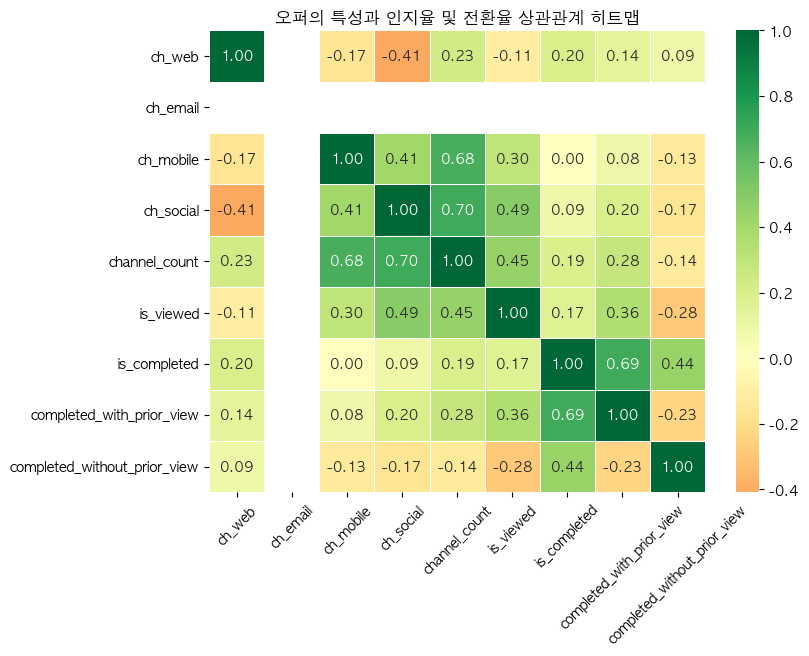

In [179]:
import seaborn as sns

ch_correlation = df[['ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'is_viewed',
                 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']].corr()
# 히트맵 (전체적인 상관관계 파악)

plt.figure(figsize=(8, 6))
sns.heatmap(ch_correlation, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)
plt.title('오퍼의 특성과 인지율 및 전환율 상관관계 히트맵')
plt.xticks(rotation=45)
plt.show() 

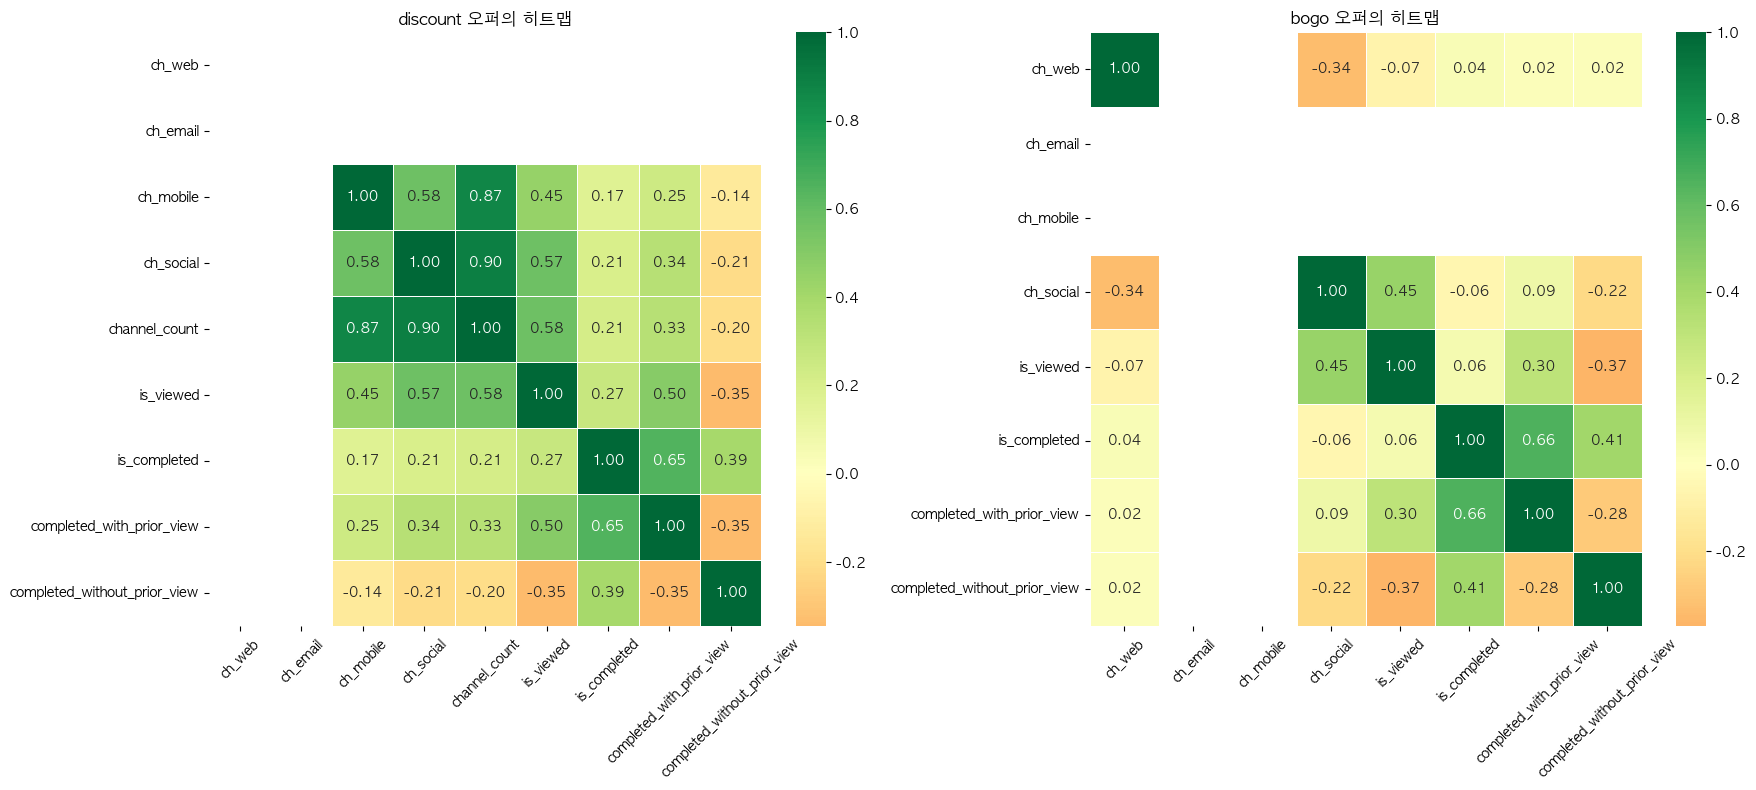

In [180]:
# bogo, discount의 지표 히트맵 시각화
import seaborn as sns

discount_df = df2[df2['offer_type']=='discount']
bogo_df = df2[df2['offer_type']=='bogo']

discount_corr = discount_df[['ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'is_viewed',
                 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']].corr()
bogo_corr = bogo_df[['ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'is_viewed',
                 'is_completed', 'completed_with_prior_view', 'completed_without_prior_view']].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

ax1 = axes[0]
ax2 = axes[1]
label = ['discount', 'bogo']

sns.heatmap(discount_corr, ax=ax1, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)
sns.heatmap(bogo_corr, ax=ax2, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)

for ax in [ax1, ax2]:
    ax.tick_params(axis='x', rotation=45)

ax1.set_title(f"{label[0]} 오퍼의 히트맵")
ax2.set_title(f"{label[1]} 오퍼의 히트맵")

plt.tight_layout()
plt.show()

In [181]:
# 특히 다음과 같이 상관관계 히트맵을 그려보았을 때 채널이 모두 활용된 경우엔 빈칸으로 되어 있기 때문에
# 완료율, 인지완료율등의 지표를 분석하기 위해서는 채널별로 구분하는 것 뿐만 아니라 오퍼 타입을 구분하여 분석할 필요가 있었다.

#### 열람후 완료율

In [182]:
bogo_df = df2[df2['offer_type']=='bogo']
discount_df = df[df['offer_type']=='discount']

# 채널 활용 유무에 따른 인지완료율 영향 : 카이제곱 독립성 검정
print("[bogo 오퍼 타입일 때]")
for ch in channels:
    print(f"\n=== {ch} 유무(0/1)와 인지완료율(completed_with_prior_view)의 독립성 검정 ===")
    ct = pd.crosstab(bogo_df[ch], bogo_df['completed_with_prior_view'])
    chi2(ct)

[bogo 오퍼 타입일 때]

=== ch_web 유무(0/1)와 인지완료율(completed_with_prior_view)의 독립성 검정 ===

p-value: 0.0005
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.0198
효과크기 미미: 무시해도 될만한 연관성

=== ch_email 유무(0/1)와 인지완료율(completed_with_prior_view)의 독립성 검정 ===

p-value: 1.0000
귀무가설 기각 실패 -> 두 변수는 독립이다 (연관성이 없다)

=== ch_mobile 유무(0/1)와 인지완료율(completed_with_prior_view)의 독립성 검정 ===

p-value: 1.0000
귀무가설 기각 실패 -> 두 변수는 독립이다 (연관성이 없다)

=== ch_social 유무(0/1)와 인지완료율(completed_with_prior_view)의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.0888
효과크기 미미: 무시해도 될만한 연관성


In [183]:
# 채널 활용 유무에 따른 인지완료율 영향 : 카이제곱 독립성 검정
print("[discount 오퍼 타입일 때]")
for ch in channels:
    print(f"\n=== {ch} 유무(0/1)와 인지완료율(completed_with_prior_view)의 독립성 검정 ===")
    ct = pd.crosstab(discount_df[ch], discount_df['completed_with_prior_view'])
    chi2(ct)

[discount 오퍼 타입일 때]

=== ch_web 유무(0/1)와 인지완료율(completed_with_prior_view)의 독립성 검정 ===

p-value: 1.0000
귀무가설 기각 실패 -> 두 변수는 독립이다 (연관성이 없다)

=== ch_email 유무(0/1)와 인지완료율(completed_with_prior_view)의 독립성 검정 ===

p-value: 1.0000
귀무가설 기각 실패 -> 두 변수는 독립이다 (연관성이 없다)

=== ch_mobile 유무(0/1)와 인지완료율(completed_with_prior_view)의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.2476
효과크기 작음: 체감도 낮은 연관성

=== ch_social 유무(0/1)와 인지완료율(completed_with_prior_view)의 독립성 검정 ===

p-value: 0.0000
귀무가설 기각 -> 두 변수는 연관성이 있다
효과크기: 0.3366
효과크기 중간: 실무적으로 유의미한 연관성


## 오퍼타입별 분석

In [184]:
print("[ 전체 오퍼 유형별 5대 지표 ]")
display(funnel_metrics(funnel, 'offer_type')
        .set_index('offer_type')
        .style.format({
            'received': '{:,}', 'viewed': '{:,}', 'completed': '{:,}',
            'aware_completed': '{:,}', 'non_aware_completed': '{:,}',
            'view_rate': '{:.1%}', 'complete_rate': '{:.1%}',
            'view_cvr': '{:.1%}', 'eff_cvr': '{:.1%}', 'no_eff_cvr': '{:.1%}',
        }))

# bogo + discount 합산 핵심 지표 출력
view_cvr_bd = bd['completed_with_prior_view'].sum() / bd['is_viewed'].sum()
print(f"\n[bogo+discount] 열람→완료(view_cvr): {view_cvr_bd:.1%}")

[ 전체 오퍼 유형별 5대 지표 ]


,received,viewed,completed,aware_completed,non_aware_completed,view_rate,complete_rate,view_cvr,eff_cvr,no_eff_cvr
offer_type,,,,,,,,,,
bogo,"30,499","25,250","15,501","9,413","4,560",82.8%,50.8%,37.3%,60.7%,29.4%
discount,"30,543","21,370","17,600","11,135","5,274",70.0%,57.6%,52.1%,63.3%,30.0%
informational,"15,235","9,947",0,0,0,65.3%,0.0%,0.0%,nan%,nan%



[bogo+discount] 열람→완료(view_cvr): 44.1%


In [185]:
# bogo / discount 전환율 비교 (informational 제외)
display(funnel_metrics(bd, 'offer_type')
        .set_index('offer_type')
        .style.format({
            'received': '{:,}', 'viewed': '{:,}', 'completed': '{:,}',
            'aware_completed': '{:,}', 'non_aware_completed': '{:,}',
            'view_rate': '{:.1%}', 'complete_rate': '{:.1%}',
            'view_cvr': '{:.1%}', 'eff_cvr': '{:.1%}', 'no_eff_cvr': '{:.1%}',
        }))

,received,viewed,completed,aware_completed,non_aware_completed,view_rate,complete_rate,view_cvr,eff_cvr,no_eff_cvr
offer_type,,,,,,,,,,
bogo,"30,499","25,250","15,501","9,413","4,560",82.8%,50.8%,37.3%,60.7%,29.4%
discount,"30,543","21,370","17,600","11,135","5,274",70.0%,57.6%,52.1%,63.3%,30.0%


In [186]:
# bogo vs discount 전환율 차이 검정 (chi-square)
for metric, col in [('수신→열람', 'is_viewed'), ('수신→완료(인지)', 'completed_with_prior_view')]:
    ct = pd.crosstab(bd['offer_type'], bd[col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"[{metric}] chi2={chi2:.1f}, p={p:.2e}, dof={dof}")
    print(f"  → {'유의미한 차이 있음 (p<0.05)' if p < 0.05 else '유의미한 차이 없음'}")

[수신→열람] chi2=1389.8, p=3.40e-304, dof=1
  → 유의미한 차이 있음 (p<0.05)
[수신→완료(인지)] chi2=213.6, p=2.30e-48, dof=1
  → 유의미한 차이 있음 (p<0.05)


In [187]:
bogo = bd[bd['offer_type'] == 'discount'].copy()
bogo['difficulty'] = bogo['difficulty'].astype(int)
# 난이도별 view_cvr
print("[ discount 난이도별 지표 ]")
display(bogo.groupby('difficulty')
         .agg(
             received  = ('instance_id',            'count'),
             viewed    = ('is_viewed',               'sum'),
             aware_comp= ('completed_with_prior_view','sum'),
         )
         .assign(view_cvr=lambda d: d['aware_comp'] / d['viewed'])
         .style.format({'received': '{:,}', 'viewed': '{:,}', 'aware_comp': '{:,}', 'view_cvr': '{:.1%}'}))

# 난이도가 view_cvr에 유의미한 영향을 주는지 — 카이제곱 독립성 검정
ct = pd.crosstab(bogo['difficulty'], bogo['completed_with_prior_view'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"[난이도 × 완료 여부] chi2={chi2:.1f}, p={p:.2e}, dof={dof}")
print(f"→ {'난이도와 view_cvr 간 유의미한 관계 있음 (p<0.05)' if p < 0.05 else '유의미한 관계 없음'}")

[ discount 난이도별 지표 ]


,received,viewed,aware_comp,view_cvr
difficulty,,,,
7,"7,646","7,330","3,884",53.0%
10,"15,229","11,388","6,034",53.0%
20,"7,668","2,652","1,217",45.9%


[난이도 × 완료 여부] chi2=2147.4, p=0.00e+00, dof=2
→ 난이도와 view_cvr 간 유의미한 관계 있음 (p<0.05)


In [188]:
bogo = bd[bd['offer_type'] == 'bogo'].copy() #discount는 변수 명 변경 
bogo['difficulty'] = bogo['difficulty'].astype(int)
# 난이도별 view_cvr
print("[ discount 난이도별 지표 ]")
display(bogo.groupby('difficulty')
         .agg(
             received  = ('instance_id',            'count'),
             viewed    = ('is_viewed',               'sum'),
             aware_comp= ('completed_with_prior_view','sum'),
         )
         .assign(view_cvr=lambda d: d['aware_comp'] / d['viewed'])
         .style.format({'received': '{:,}', 'viewed': '{:,}', 'aware_comp': '{:,}', 'view_cvr': '{:.1%}'}))

# 난이도가 view_cvr에 유의미한 영향을 주는지 — 카이제곱 독립성 검정
ct = pd.crosstab(bogo['difficulty'], bogo['completed_with_prior_view'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"[난이도 × 완료 여부] chi2={chi2:.1f}, p={p:.2e}, dof={dof}")
print(f"→ {'난이도와 view_cvr 간 유의미한 관계 있음 (p<0.05)' if p < 0.05 else '유의미한 관계 없음'}")

[ discount 난이도별 지표 ]


,received,viewed,aware_comp,view_cvr
difficulty,,,,
5,"15,248","11,336","4,816",42.5%
10,"15,251","13,914","4,597",33.0%


[난이도 × 완료 여부] chi2=7.4, p=6.65e-03, dof=1
→ 난이도와 view_cvr 간 유의미한 관계 있음 (p<0.05)


In [189]:
# bogo / discount만 사용 (열람자만 — view_cvr 기준)
bd_v = bd[bd['is_viewed'] == 1].copy()

# 오퍼 유형별 로지스틱: difficulty 계수 비교
# → 계수가 더 음수인 쪽이 난이도 상승에 더 민감
results = []
for otype, grp in bd_v.groupby('offer_type'):
    m = smf.logit('completed_with_prior_view ~ difficulty', data=grp).fit(disp=False)
    coef = m.params['difficulty']
    pval = m.pvalues['difficulty']
    results.append({
        'offer_type': otype,
        'difficulty 계수(log-odds)': round(coef, 4),
        'odds ratio': round(np.exp(coef), 4),
        'p-value': f'{pval:.2e}',
        '유의여부': '유의' if pval < 0.05 else '비유의',
    })
display(pd.DataFrame(results).set_index('offer_type'))

,difficulty 계수(log-odds),odds ratio,p-value,유의여부
offer_type,,,,
bogo,-0.0807,0.9225,1.46e-53,유의
discount,-0.0224,0.9779,1.48e-10,유의


In [190]:
# 오퍼 유형별 duration 분포
dur_dist = (
    funnel.groupby(['offer_type', 'duration'])
    .size()
    .reset_index(name='건수')
)
dur_pivot = dur_dist.pivot(index='offer_type', columns='duration', values='건수').fillna(0).astype(int)
display(dur_pivot.style.format('{:,}'))

duration,3.000000,4.000000,5.000000,7.000000,10.000000
offer_type,,,,,
bogo,0,0,"15,164","15,335",0
discount,0,0,0,"15,278","15,265"
informational,"7,618","7,617",0,0,0


In [191]:
funnel['duration'] = funnel['duration'].astype(int)
dur_dist = (
    funnel.groupby(['offer_type', 'duration'])
    .size()
    .reset_index(name='건수')
)
dur_pivot = dur_dist.pivot(index='offer_type', columns='duration', values='건수').fillna(0).astype(int)
display(dur_pivot.style.format('{:,}'))

duration,3,4,5,7,10
offer_type,,,,,
bogo,0,0,"15,164","15,335",0
discount,0,0,0,"15,278","15,265"
informational,"7,618","7,617",0,0,0


In [192]:
# 채널 수 × 오퍼 유형별 5대 지표
bd['channel_count'] = bd['channel_count'].astype(int)
display(bd.groupby(['channel_count', 'offer_type'])
         .agg(
             received  = ('instance_id',            'count'),
             viewed    = ('is_viewed',               'sum'),
             aware_comp= ('completed_with_prior_view','sum'),
         )
         .assign(view_cvr=lambda d: d['aware_comp'] / d['viewed'])
         .style.format({'received': '{:,}', 'viewed': '{:,}', 'aware_comp': '{:,}', 'view_cvr': '{:.1%}'}))

In [193]:
# view_cvr 기준: 열람자 중 열람 후 완료
bd_ch_viewed = bd[bd['is_viewed'] == 1].copy()

ct_ch = pd.crosstab(bd_ch_viewed['channel_count'], bd_ch_viewed['completed_with_prior_view'])
chi2, p, dof, _ = stats.chi2_contingency(ct_ch)
print(f"[채널 수 × view_cvr] chi2={chi2:.1f}, p={p:.2e}, dof={dof}")
print(f"→ {'채널 수와 view_cvr 간 유의미한 관계 있음 (p<0.05)' if p < 0.05 else '유의미한 관계 없음'}")

r, p_sp = stats.spearmanr(bd_ch_viewed['channel_count'], bd_ch_viewed['completed_with_prior_view'].astype(int))
print(f"채널 수 ↔ view_cvr 스피어만: r={r:.3f}, p={p_sp:.2e}")
print(f"→ {'채널이 많을수록 view_cvr 높음' if r > 0 and p_sp < 0.05 else '채널이 많을수록 view_cvr 낮음' if r < 0 and p_sp < 0.05 else '유의미한 방향성 없음'}")

[채널 수 × view_cvr] chi2=143.8, p=5.87e-32, dof=2
→ 채널 수와 view_cvr 간 유의미한 관계 있음 (p<0.05)
채널 수 ↔ view_cvr 스피어만: r=0.044, p=1.60e-21
→ 채널이 많을수록 view_cvr 높음


## 오퍼간격별 분석

In [194]:
# BOGO vs Discount — 완료 소요 시간 

# gap_to_complete은 is_completed인 행만 non-null
bogo_gap = funnel.loc[(funnel['offer_type'] == 'bogo') & funnel['is_completed'] & funnel['completed_with_prior_view'], 'gap_to_complete']
disc_gap = funnel.loc[(funnel['offer_type'] == 'discount') & funnel['is_completed'] & funnel['completed_with_prior_view'], 'gap_to_complete']

for name, s in [('bogo', bogo_gap), ('discount', disc_gap)]:
    print(f"{name} 완료 건수: {len(s):,}  중앙값: {s.median()/24:.1f}일  평균: {s.mean()/24:.1f}일")

# 완료 시간 분포는 비정규 가정 (right-skewed 특성상) → Mann-Whitney U
u_stat, p_val = stats.mannwhitneyu(bogo_gap, disc_gap, alternative='two-sided')
n1, n2 = len(bogo_gap), len(disc_gap)
r = 1 - (2 * u_stat) / (n1 * n2)
print('')
print("=" *50)
print(" Mann-Whitney U test")
print("=" *50)
print(f"U={u_stat:.0f}, p={p_val:.2e}")

if p_val < 0.05:
    diff = (disc_gap.median() - bogo_gap.median()) / 24
    print(f"→ p < 0.05: bogo가 discount보다 평균 {diff:.1f}일 빠르게 완료됨")
else:
    print("→ p >= 0.05: 유의미한 차이 없음")

print(f"효과 크기 (rank-biserial r) = {r:.3f}")
print(f"→ {'작음 (|r|<0.1)' if abs(r)<0.1 else '중간 (0.1≤|r|<0.3)' if abs(r)<0.3 else '큰 편 (|r|≥0.3)'}")

bogo 완료 건수: 9,413  중앙값: 2.2일  평균: 2.4일
discount 완료 건수: 11,135  중앙값: 2.8일  평균: 3.3일

 Mann-Whitney U test
U=41749656, p=6.49e-140
→ p < 0.05: bogo가 discount보다 평균 0.5일 빠르게 완료됨
효과 크기 (rank-biserial r) = 0.203
→ 중간 (0.1≤|r|<0.3)


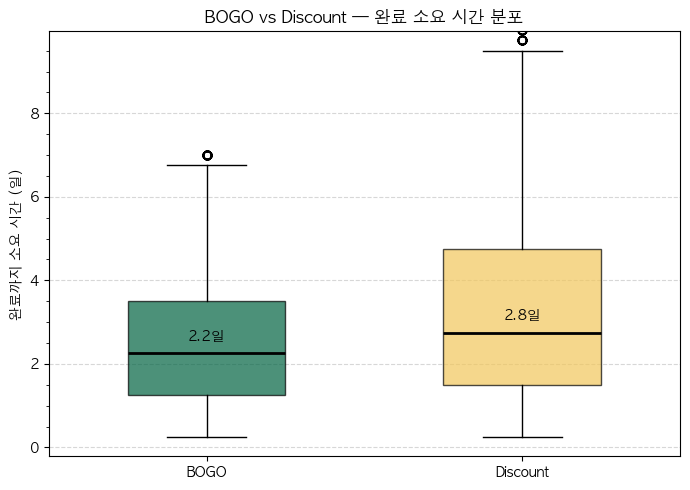

In [195]:
# BOGO vs Discount — 완료 소요 시간 분포
import matplotlib.ticker as ticker

plot_df = funnel[funnel['offer_type'].isin(['bogo', 'discount']) & funnel['is_completed'] & funnel['completed_with_prior_view']].copy()
plot_df['gap_days'] = plot_df['gap_to_complete'] / 24

fig, ax = plt.subplots(figsize=(7, 5))

groups = [
    plot_df.loc[plot_df['offer_type'] == 'bogo', 'gap_days'],
    plot_df.loc[plot_df['offer_type'] == 'discount', 'gap_days'],
]
bp = ax.boxplot(groups, labels=['BOGO', 'Discount'],
                patch_artist=True, widths=0.5,
                medianprops=dict(color='black', linewidth=2))

colors = ['#006241', '#F2C75C']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# 실제 whisker 끝값 기준으로 ylim 설정
whisker_bottoms = [w.get_ydata()[1] for w in bp['whiskers'][0::2]]
whisker_tops = [w.get_ydata()[1] for w in bp['whiskers'][1::2]]
margin = (max(whisker_tops) - min(whisker_bottoms)) * 0.05
ax.set_ylim(min(whisker_bottoms) - margin, max(whisker_tops) + margin)

ax.set_ylabel('완료까지 소요 시간 (일)')
ax.set_title('BOGO vs Discount — 완료 소요 시간 분포')
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis='y', linestyle='--', alpha=0.5)

# 중앙값 텍스트 표시
for i, g in enumerate(groups, 1):
    ax.text(i, g.median() + margin * 0.5, f'{g.median():.1f}일',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [196]:
# BOGO vs Discount — 열람 소요 시간 분포
bogo_view = funnel.loc[(funnel['offer_type'] == 'bogo') & funnel['is_viewed'], 'gap_to_view']
disc_view  = funnel.loc[(funnel['offer_type'] == 'discount') & funnel['is_viewed'], 'gap_to_view']

for name, s in [('bogo', bogo_view), ('discount', disc_view)]:
    print(f"{name} 열람 건수: {len(s):,}  중앙값: {s.median()/24:.1f}일  평균: {s.mean()/24:.1f}일")

u_stat, p_val = stats.mannwhitneyu(bogo_view, disc_view, alternative='two-sided')
n1, n2 = len(bogo_view), len(disc_view)
r = 1 - (2 * u_stat) / (n1 * n2)
print('')
print("=" *50)
print(f"Mann-Whitney U test (열람 속도)")
print("=" *50)
print(f" U={u_stat:.0f}, p={p_val:.2e}")
if p_val < 0.05:
    diff = (disc_view.median() - bogo_view.median()) / 24
    faster = 'bogo' if diff > 0 else 'discount'
    print(f"→ p < 0.05: {faster}가 {abs(diff):.1f}일 빠르게 열람됨")
else:
    print("→ p >= 0.05: 유의미한 차이 없음")

print(f"효과 크기 (rank-biserial r) = {r:.3f}")
print(f"→ {'작음 (|r|<0.1)' if abs(r)<0.1 else '중간 (0.1≤|r|<0.3)' if abs(r)<0.3 else '큰 편 (|r|≥0.3)'}")

bogo 열람 건수: 25,250  중앙값: 0.5일  평균: 1.0일
discount 열람 건수: 21,370  중앙값: 0.5일  평균: 1.1일

Mann-Whitney U test (열람 속도)
 U=263321120, p=6.28e-06
→ p < 0.05: discount가 0.0일 빠르게 열람됨
효과 크기 (rank-biserial r) = 0.024
→ 작음 (|r|<0.1)


In [197]:
# 열람 후 완료까지 걸리는 시간 분포
display(funnel[funnel['completed_with_prior_view'] == 1]
        .groupby('offer_type')['gap_view_to_complete']
        .median()
        .to_frame('중앙값(시간)')
        .style.format({'중앙값(시간)': '{:.1f}'}))

,중앙값(시간)
offer_type,
bogo,30.0
discount,42.0


[ 열람 후 완료까지 소요 시간 ]
  bogo: n=9,413  중앙값=1.2일  평균=1.7일
  discount: n=11,135  중앙값=1.8일  평균=2.4일
Mann-Whitney U: U=42782219, p=8.75e-115
효과 크기 r=0.184 → 중간


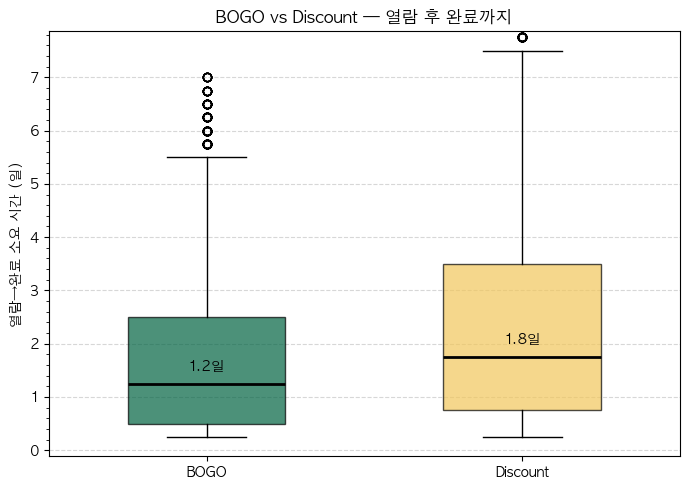

In [198]:
# --- gap_view_to_complete 분포 (열람 후 완료까지) ---
print("[ 열람 후 완료까지 소요 시간 ]")
for otype, grp in bd.groupby('offer_type'):
    s = grp.loc[grp['completed_with_prior_view']==1, 'gap_view_to_complete'].dropna()
    print(f"  {otype}: n={len(s):,}  중앙값={s.median()/24:.1f}일  평균={s.mean()/24:.1f}일")

bogo_vc = bd.loc[(bd['offer_type'] == 'bogo') & bd['gap_view_to_complete'].notna() & bd['completed_with_prior_view'], 'gap_view_to_complete']
disc_vc = bd.loc[(bd['offer_type'] == 'discount') & bd['gap_view_to_complete'].notna() & bd['completed_with_prior_view'], 'gap_view_to_complete']
u, p = stats.mannwhitneyu(bogo_vc, disc_vc, alternative='two-sided')
n1, n2 = len(bogo_vc), len(disc_vc)
r = 1 - (2 * u) / (n1 * n2)
print(f"Mann-Whitney U: U={u:.0f}, p={p:.2e}")
print(f"효과 크기 r={r:.3f} → {'작음' if abs(r)<0.1 else '중간' if abs(r)<0.3 else '큰 편'}")

# 박스플롯
fig, ax = plt.subplots(figsize=(7, 5))
groups = [bogo_vc / 24, disc_vc / 24]
bp = ax.boxplot(groups, labels=['BOGO', 'Discount'],
                patch_artist=True, widths=0.5,
                medianprops=dict(color='black', linewidth=2))

colors = ['#006241', '#F2C75C']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

whisker_bottoms = [w.get_ydata()[1] for w in bp['whiskers'][0::2]]
whisker_tops    = [w.get_ydata()[1] for w in bp['whiskers'][1::2]]
margin = (max(whisker_tops) - min(whisker_bottoms)) * 0.05
ax.set_ylim(min(whisker_bottoms) - margin, max(whisker_tops) + margin)

ax.set_ylabel('열람→완료 소요 시간 (일)')
ax.set_title('BOGO vs Discount — 열람 후 완료까지')
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis='y', linestyle='--', alpha=0.5)

# 중앙값 텍스트 표시
for i, g in enumerate(groups, 1):
    ax.text(i, g.median() + margin * 0.5, f'{g.median():.1f}일',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

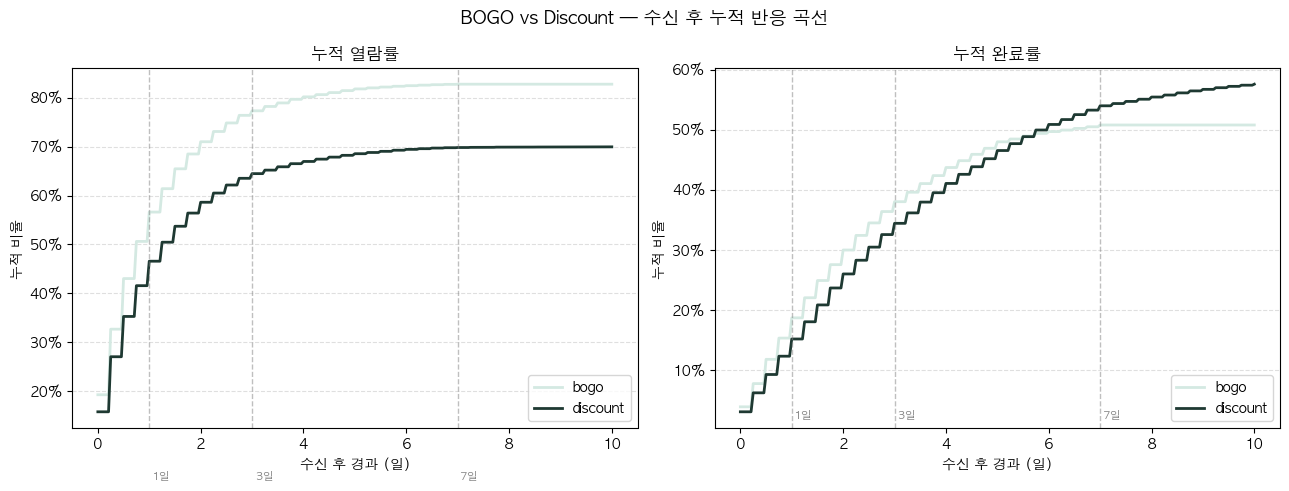


[주요 시점별 반응률 테이블]


,열람_6h,완료_6h,열람_24h,완료_24h,열람_48h,완료_48h,열람_72h,완료_72h,열람_168h,완료_168h,유효기간내_완료
offer_type,,,,,,,,,,,
bogo,0.33,0.08,0.57,0.19,0.71,0.30,0.77,0.38,0.83,0.51,0.51
discount,0.27,0.06,0.47,0.15,0.59,0.26,0.64,0.34,0.70,0.54,0.58



[열람 타이밍 구간별 완료율]


,n,완료 건수,완료율(%),95%CI 하한(%),95%CI 상한(%)
열람 타이밍,,,,,
6h내,21758,9507,43.7,43.0,44.4
6~24h,16314,6138,37.6,36.9,38.4
24~48h,10147,3101,30.6,29.7,31.5
48~72h,4776,1157,24.2,23.0,25.5
72h+,3572,645,18.1,16.8,19.4


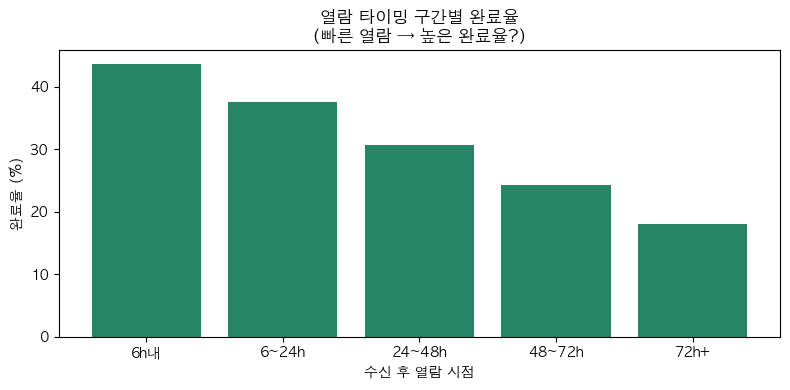

In [199]:
from statsmodels.stats.proportion import proportion_confint

# --- 누적 반응 곡선 ---
time_points = np.arange(0, 24 * 10 + 1, 1)
days = time_points / 24

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
colors = {'bogo': '#D4E9E2', 'discount': '#1E3932'}

for otype, grp in bd.groupby('offer_type'):
    n = len(grp)
    cum_view = [(grp['gap_to_view'].dropna() <= t).sum() / n for t in time_points]
    cum_comp = [(grp['gap_to_complete'].dropna() <= t).sum() / n for t in time_points]

    axes[0].plot(days, cum_view, label=otype, color=colors[otype], linewidth=2)
    axes[1].plot(days, cum_comp, label=otype, color=colors[otype], linewidth=2)

for ax, title in zip(axes, ['누적 열람률', '누적 완료률']):
    ax.set_xlabel('수신 후 경과 (일)')
    ax.set_ylabel('누적 비율')
    ax.set_title(title)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.axvline(1, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(3, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(7, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(1.05, 0.02, '1일', color='gray', fontsize=8)
    ax.text(3.05, 0.02, '3일', color='gray', fontsize=8)
    ax.text(7.05, 0.02, '7일', color='gray', fontsize=8)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('BOGO vs Discount — 수신 후 누적 반응 곡선', fontsize=13)
plt.tight_layout()
plt.show()

# --- 주요 시점별 반응률 테이블 ---
thresholds = [6, 24, 48, 72, 168]
rows = []
for otype, grp in bd.groupby('offer_type'):
    n = len(grp)
    row = {'offer_type': otype}
    for t in thresholds:
        row[f'열람_{t}h'] = (grp['gap_to_view'].dropna() <= t).sum() / n
        row[f'완료_{t}h'] = (grp['gap_to_complete'].dropna() <= t).sum() / n
    row['유효기간내_완료'] = (
        grp['is_completed'] & (grp['gap_to_complete'] <= grp['duration'].fillna(0) * 24)
    ).sum() / n
    rows.append(row)

summary = pd.DataFrame(rows).set_index('offer_type').round(2)
print("")
print("[주요 시점별 반응률 테이블]")
display(summary)

# --- 열람 타이밍 구간별 완료율 ---
viewed_df = funnel[funnel['is_viewed'] == True].copy()

bins = [-1, 6, 24, 48, 72, float('inf')]
labels = ['6h내', '6~24h', '24~48h', '48~72h', '72h+']
viewed_df['view_timing'] = pd.cut(viewed_df['gap_to_view'], bins=bins, labels=labels, right=True)

timing_summary = (
    viewed_df.groupby('view_timing', observed=True)
    .agg(
        n=('completed_with_prior_view', 'count'),
        completed=('completed_with_prior_view', 'sum')  # ← 미인지 완료 제외
    )
    .reset_index()
)
timing_summary['완료율(%)'] = (timing_summary['completed'] / timing_summary['n'] * 100).round(1)

# CI 계산
ci_rows = []
for _, row in timing_summary.iterrows():
    lo, hi = proportion_confint(int(row['completed']), int(row['n']), method='wilson')
    ci_rows.append({
        '열람 타이밍': row['view_timing'],
        'n': int(row['n']),
        '완료 건수': int(row['completed']),
        '완료율(%)': row['완료율(%)'],
        '95%CI 하한(%)': round(lo * 100, 1),
        '95%CI 상한(%)': round(hi * 100, 1),
    })
print("")
print("[열람 타이밍 구간별 완료율]")
display(pd.DataFrame(ci_rows).set_index('열람 타이밍'))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(timing_summary['view_timing'].astype(str), timing_summary['완료율(%)'],
       color='#00704A', alpha=0.85)
ax.set_title('열람 타이밍 구간별 완료율\n(빠른 열람 → 높은 완료율?)', fontweight='bold')
ax.set_xlabel('수신 후 열람 시점')
ax.set_ylabel('완료율 (%)')
plt.tight_layout()
plt.show()

In [200]:
bd_dur = bd.copy()
bd_dur['duration'] = bd_dur['duration'].astype(int)

# --- duration 길이별 5대 지표 (view_cvr 기준) ---
dur_rate = (bd_dur.groupby(['offer_type', 'duration'])
            .agg(
                received  = ('instance_id',             'count'),
                viewed    = ('is_viewed',                'sum'),
                aware_comp= ('completed_with_prior_view','sum'),
            )
            .assign(view_cvr=lambda d: d['aware_comp'] / d['viewed']))
display(dur_rate.style.format({
    'received': '{:,}', 'viewed': '{:,}', 'aware_comp': '{:,}', 'view_cvr': '{:.1%}'
}))

# --- [검정 1] duration=7 조건에서 bogo vs discount view_cvr 비교 ---
dur7_viewed = bd_dur[(bd_dur['duration'] == 7) & (bd_dur['is_viewed'] == 1)]
ct = pd.crosstab(dur7_viewed['offer_type'], dur7_viewed['completed_with_prior_view'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
display(pd.DataFrame([{
    '검정': 'bogo vs discount view_cvr (duration=7)',
    'chi2': round(chi2, 1), 'p': f'{p:.2e}', 'V': round(v, 3),
    '유의여부': '유의' if p < 0.05 else '비유의',
}]))

# --- [검정 2] 오퍼 유형별 duration 변화에 따른 view_cvr 차이 ---
# bogo: duration 5 vs 7 / discount: duration 7 vs 10
chi_rows = []
for otype, grp in bd_dur.groupby('offer_type'):
    grp_viewed = grp[grp['is_viewed'] == 1]
    ct2 = pd.crosstab(grp_viewed['duration'], grp_viewed['completed_with_prior_view'])
    chi2_2, p_2, _, _ = stats.chi2_contingency(ct2)
    v_2 = np.sqrt(chi2_2 / (ct2.values.sum() * (min(ct2.shape) - 1)))

    # duration별 view_cvr 계산
    cvr_by_dur = (grp_viewed.groupby('duration')['completed_with_prior_view']
                  .agg(['sum', 'count'])
                  .assign(view_cvr=lambda x: x['sum'] / x['count']))
    cvr_vals   = cvr_by_dur['view_cvr'].sort_index()
    cvr_str    = ' → '.join([f"{dur}일:{v:.1%}" for dur, v in cvr_vals.items()])
    cvr_diff   = cvr_vals.iloc[-1] - cvr_vals.iloc[0]

    chi_rows.append({
        'offer_type'     : otype,
        'duration별 view_cvr' : cvr_str,
        'view_cvr 변화'  : f'{cvr_diff:+.1%}',
        'chi2'           : round(chi2_2, 1),
        'p'              : f'{p_2:.2e}',
        'V'              : round(v_2, 3),
        '유의여부'       : '유의' if p_2 < 0.05 else '비유의',
    })
display(pd.DataFrame(chi_rows).set_index('offer_type'))

,검정,chi2,p,V,유의여부
0,bogo vs discount view_cvr (duration=7),379.9,1.28e-84,0.131,유의


,duration별 view_cvr,view_cvr 변화,chi2,p,V,유의여부
offer_type,,,,,,
bogo,5일:37.0% → 7일:37.6%,+0.6%,1.0,3.08e-01,0.006,비유의
discount,7일:50.7% → 10일:53.8%,+3.1%,20.5,6.04e-06,0.031,유의


In [201]:
# --- 동일 오퍼 재수신 간격 vs 완료율 ---
multi = (funnel.sort_values(['customer_id', 'offer_id', 't_received'])
               .copy())
multi['aware_completed'] = multi['is_completed'] & multi['completed_with_prior_view']
multi['recv_gap'] = (multi.groupby(['customer_id', 'offer_id'])['t_received']
                          .diff())

multi_only = multi[multi['recv_gap'].notna()].copy()

# 기술통계
display(pd.DataFrame([{
    '재수신 인스턴스 수': f"{len(multi_only):,}건",
    '재수신 간격 중앙값': f"{multi_only['recv_gap'].median()/24:.1f}일",
    '재수신 간격 평균': f"{multi_only['recv_gap'].mean()/24:.1f}일",
}]))

# 스피어만 상관
r, p = stats.spearmanr(multi_only['recv_gap'], multi_only['aware_completed'].astype(int))
display(pd.DataFrame([{
    'r': round(r, 3),
    'p': f'{p:.2e}',
    '해석': '유의미한 관계 있음' if p < 0.05 else '유의미한 관계 없음',
}]).set_index('r'))

,재수신 인스턴스 수,재수신 간격 중앙값,재수신 간격 평균
0,"12,989건",7.0일,10.5일


,p,해석
r,,
0.009,2.99e-01,유의미한 관계 없음


In [202]:
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.proportion import proportion_confint

# --- 몇 번째 수신에서 처음 열람하는가 ---
fv = first_viewed_instance.copy()

# 분포
dist = fv['first_viewed_instance'].value_counts().sort_index()
dist_pct = dist / dist.sum() * 100

dist_df = pd.DataFrame({
    '수신 차수': [f"{inst}번째 수신" for inst in dist.index],
    '건수': dist.values,
    '비율(%)': dist_pct.values.round(1),
}).set_index('수신 차수')
display(dist_df.style.format({'건수': '{:,}', '비율(%)': '{:.1f}%'}))

re_send_view_rate = (fv['first_viewed_instance'] >= 2).mean()
display(pd.DataFrame([{
    '재발송 후 첫 열람 비율': f'{re_send_view_rate:.1%}',
    '첫 수신에서 바로 열람': f'{1 - re_send_view_rate:.1%}',
}]))

# 재발송 간격별 열람율 (첫 인스턴스 열람이 아닌 경우만)
bins   = [0, 24, 72, 168, float('inf')]
labels = ['1일 이내', '1~3일', '3~7일', '7일 초과']

resend = (
    multi
    .query('instance_id >= 2')
    .dropna(subset=['recv_gap'])
    .copy()
)
resend['gap_bin'] = pd.cut(resend['recv_gap'], bins=bins, labels=labels)

gap_open = (
    resend.groupby('gap_bin', observed=True)
    .agg(
        발송수=('is_viewed', 'count'),
        열람수=('is_viewed', 'sum'),
    )
    .assign(열람율=lambda x: x['열람수'] / x['발송수'])
)
display(gap_open.style.format({'발송수': '{:,}', '열람수': '{:,}', '열람율': '{:.1%}'}))

,건수,비율(%)
수신 차수,,
1번째 수신,"47,024",97.5%
2번째 수신,"1,146",2.4%
3번째 수신,42,0.1%
4번째 수신,1,0.0%


,재발송 후 첫 열람 비율,첫 수신에서 바로 열람
0,2.5%,97.5%


,발송수,열람수,열람율
gap_bin,,,
1~3일,"1,921","1,443",75.1%
3~7일,"4,604","3,365",73.1%
7일 초과,"6,464","4,735",73.3%
